# Pneumonia Detection from Chest X-Rays — Transfer Learning with ResNet-18

**Educational project — not validated for clinical use.**

Pneumonia is one of the leading causes of illness and death worldwide, and timely
radiological review is central to treatment decisions. This notebook fine-tunes a
pretrained ResNet-18 to classify pediatric chest X-rays as **NORMAL** or **PNEUMONIA**.

The goal here goes beyond a single accuracy number: the notebook demonstrates a
methodologically sound *starting point* for a small clinical imaging dataset, and is
equally explicit about where that methodology still falls short — an evaluation set
reused across many comparisons rather than observed once, single-run experiments that
aren't fully isolated from each other, and a backbone that's frozen in one sense (no
gradient updates) but not another (BatchNorm statistics still adapt). Naming these
limitations precisely, not only the ones that flatter the result, is the point.

**Headline number** (evaluation set, n=100, threshold 0.5):
**accuracy 0.76 [95% CI 0.66–0.84] · F1 0.81 (positive-class) · sensitivity 1.00
[0.93–1.00] · specificity 0.52 [0.37–0.66]** (exact Clopper-Pearson intervals). This
set was examined repeatedly across steps 6, 9–12, and 15 to compare candidate models —
see *Conclusions & Limitations* for what that does to how these numbers should be read,
and why this is not a clinical validation.

**External validation** (step 17, RSNA Pneumonia Detection Challenge, n=14,863, a
different institution/population/label definition): the model does **not** beat a
trivial prevalence-matched baseline, pooled or in either view-stratified subgroup. This
is the more honest headline for anyone deciding whether this model generalizes at all —
the internal number above answers a narrower question than it might appear to.

**Contents**
1. Exploratory Data Analysis
2. Transfer Learning Setup
3. Baseline Training *(a deliberately naive first pass, kept for contrast)*
4. Diagnosing the Baseline
5. Fixing the Methodology — validation split & best-checkpoint selection
6. Evaluation on the Held-Out Set
7. Explainability with Grad-CAM
8. Model Persistence
9. Testing a Hypothesis — Framing-Robust Augmentation *(a single exploratory run)*
10. Deeper Fine-Tuning — Unfreezing `layer4` *(overfits; beats step 6 in aggregate — this run)*
11. Completing the 2×2 — Augmentation × `layer4` *(best raw numbers, still just one run)*
12. ROC/PR Curves and Threshold Calibration
13. Quantifying the Border-Attention Pattern
14. Bootstrap Confidence Intervals
15. Removing the Border Cue at the Source: Masked Preprocessing *(smallest, steadiest improvement)*
16. Repeating the 2×2 Grid Across Seeds — Breaking n=1 (retires step 11's headline number)
17. External Validation: RSNA Pneumonia Detection Challenge *(does not beat a trivial baseline)*

Conclusions & Limitations

## Original Assignment Brief

Pneumonia is one of the leading respiratory illnesses worldwide, and its timely and accurate diagnosis is essential for effective treatment. Manually reviewing chest X-rays is a critical step in this process, and AI can provide valuable support by helping to expedite the assessment. In your role as a consultant data scientist, you will test the ability of a deep learning model to distinguish pneumonia cases from normal images of lungs in chest X-rays.

By fine-tuning a pre-trained convolutional neural network, specifically the ResNet-18 model, your task is to classify X-ray images into two categories: normal lungs and those affected by pneumonia. You can leverage its already trained weights and get an accurate classifier trained faster and with fewer resources.

### The Data

<img src="x-rays_sample.png" align="center"/>
&nbsp

You have a dataset of chest X-rays that have been preprocessed for use with a ResNet-18 model. You can see a sample of 5 images from each category above. Upon unzipping the `chestxrays.zip` file (code provided below), you will find your dataset inside the `data/chestxrays` folder divided into `test` and `train` folders.

There are 150 training images and 50 testing images for each category, NORMAL and PNEUMONIA (300 and 100 in total). For your convenience, this data has already been loaded into a `train_loader` and a `test_loader` using the `DataLoader` class from the PyTorch library.

In [1]:
%matplotlib inline

# Import required libraries
# -------------------------
# Data loading
import random
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Train model
import torch
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# Evaluate model
from torchmetrics import Accuracy, F1Score

# Set random seeds for reproducibility
torch.manual_seed(101010)
np.random.seed(101010)
random.seed(101010)

In [2]:
import os
import zipfile

# Unzip the data folder
if not os.path.exists('data/chestxrays'):
    with zipfile.ZipFile('data/chestxrays.zip', 'r') as zip_ref:
        zip_ref.extractall('data')

In [3]:
# Define the transformations to apply to the images for use with ResNet-18
transform_mean = [0.485, 0.456, 0.406]
transform_std =[0.229, 0.224, 0.225]
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=transform_mean, std=transform_std)])

# Apply the image transforms
train_dataset = ImageFolder('data/chestxrays/train', transform=transform)
test_dataset = ImageFolder('data/chestxrays/test', transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset) // 2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

## 1. Exploratory Data Analysis

Before touching the model, we look at the data. In medical imaging, models most often
fail because of the data — artifacts, class imbalance, leakage between splits — not
because of the architecture.

We check three things:
1. **Label mapping** — `ImageFolder` assigns classes alphabetically, so we expect
   `NORMAL=0`, `PNEUMONIA=1`. This needs to be *verified*, not assumed — it determines
   how the sigmoid output is interpreted at evaluation time.
2. **Class balance** — computed from the data, not taken on faith from the task description.
3. **Raw images** — do we see the expected disease signature (whitish consolidation in
   the lung fields)? And do the two classes differ in ways *unrelated* to disease (film
   markers, contrast, framing)? This is the risk of **shortcut learning** — a model can
   learn to recognize the imaging equipment or acquisition protocol instead of the
   pathology itself.

In [4]:
# 1a. Label mapping and class balance
# ------------------------------------
from collections import Counter

# ImageFolder assigns class indices alphabetically
print("Class mapping:", {name: idx for idx, name in enumerate(train_dataset.classes)})

# .targets holds every label in the dataset — we count rather than trust the description
train_counts = Counter(train_dataset.targets)
test_counts = Counter(test_dataset.targets)

for name, idx in train_dataset.class_to_idx.items():
    print(f"{name:10s}  train: {train_counts[idx]:3d}   test: {test_counts[idx]:3d}")

Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL      train: 150   test:  50
PNEUMONIA   train: 150   test:  50


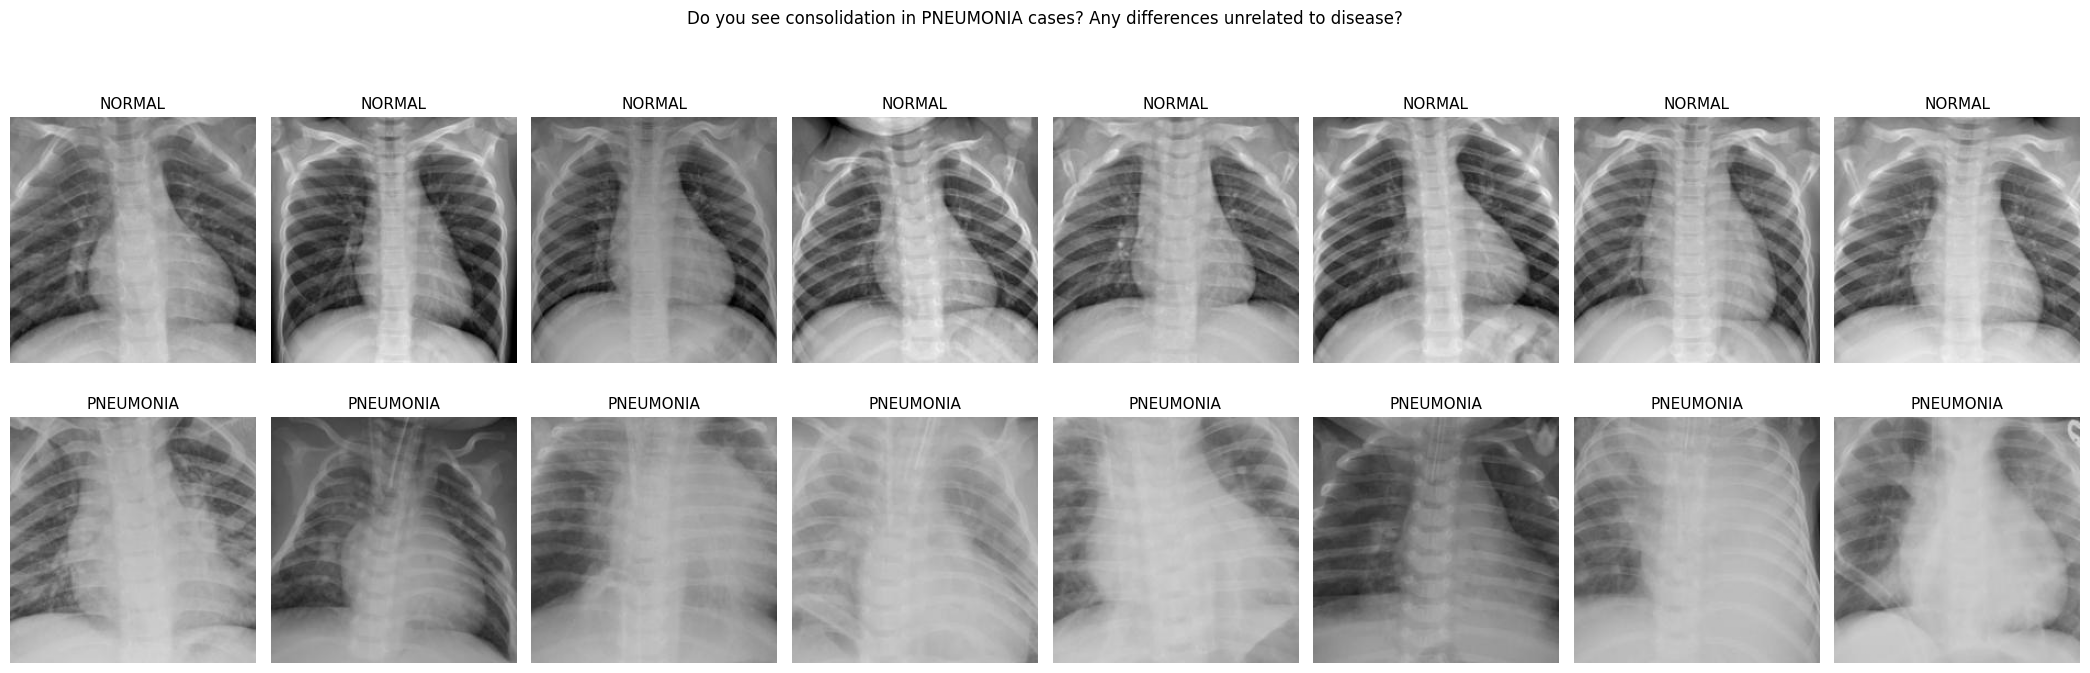

In [5]:
# 1b. Sampling raw images (top row: NORMAL, bottom row: PNEUMONIA)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

# Tensors are normalized for ImageNet — to see the "real" X-ray we invert it:
# x_norm = (x - mean) / std  =>  x = x_norm * std + mean
mean = torch.tensor(transform_mean).view(3, 1, 1)   # (3,1,1) so it broadcasts across channels
std = torch.tensor(transform_std).view(3, 1, 1)

def denormalize(img):
    return (img * std + mean).clamp(0, 1)

# A dedicated, seeded generator for sampling — the first 8 images by index would be an
# arbitrary (alphabetical-by-filename) slice, not a representative look at the data
eda_rng = np.random.default_rng(101010)
normal_all = [i for i, t in enumerate(train_dataset.targets) if t == 0]
pneumonia_all = [i for i, t in enumerate(train_dataset.targets) if t == 1]
normal_idx = eda_rng.choice(normal_all, size=8, replace=False)
pneumonia_idx = eda_rng.choice(pneumonia_all, size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(21, 7))
for ax, idx in zip(axes.flat, list(normal_idx) + list(pneumonia_idx)):
    img, label = train_dataset[idx]                 # (3, 224, 224) — channels first
    img = denormalize(img).permute(1, 2, 0)         # imshow wants (224, 224, 3) — channels last
    ax.imshow(img)
    ax.set_title(train_dataset.classes[label], fontsize=11)
    ax.axis("off")

fig.suptitle("Do you see consolidation in PNEUMONIA cases? Any differences unrelated to disease?", y=1.02)
plt.tight_layout()
plt.show()

## 2. Transfer Learning Setup

ResNet-18 was pretrained on ImageNet: 1.2M natural images, 1000 classes (dogs, cars,
…). Why does that help with X-rays? Because **early CNN layers learn general-purpose
features** — edges, textures, brightness gradients — and only the later layers assemble
those into task-specific concepts. Edges and textures are just as useful on a chest
X-ray as on a photo of a dog. (Empirically, ImageNet features transfer to medical
imaging surprisingly well despite the domain gap — this is a standard starting point in
radiology ML.)

Model surgery:
1. **Freeze the entire backbone** (`requires_grad = False`) — leaves ~11M parameters
   untouched. With only 300 training images, fine-tuning the full network would overfit
   almost immediately: the model would memorize the training set instead of generalizing.
2. **Replace the head**: the original `fc` is `Linear(512 → 1000)` (ImageNet classes).
   We swap in a fresh, trainable `Linear(512 → 1)`.

Why **one output, not two**? For binary classification a single logit is enough:
`sigmoid(logit)` gives the probability of class `1` — PNEUMONIA, per the mapping
confirmed in step 1. Two outputs plus softmax would be mathematically equivalent, but
the provided evaluation code later in this notebook expects the sigmoid formulation, so
the loss function in step 3 is matched to it.

In [6]:
# 2a. Load the pretrained ResNet-18
# -------------------------------------
# Pretrained weights download to TORCH_HOME — pointed at ./models (mounted from the
# host) so they survive container restarts instead of re-downloading every time
os.environ["TORCH_HOME"] = "models"

resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

total_params = sum(p.numel() for p in resnet18.parameters())
print(f"Total parameters: {total_params:,}")
print("Original head:", resnet18.fc)  # Linear(512 -> 1000 ImageNet classes)

Total parameters: 11,689,512
Original head: Linear(in_features=512, out_features=1000, bias=True)


In [7]:
# 2b. Freeze the backbone, replace the head
# --------------------------------------------
for param in resnet18.parameters():
    param.requires_grad = False

# The new layer has requires_grad=True by default — it's the only thing we'll train.
# in_features is read off the model rather than hardcoded as 512
resnet18.fc = nn.Linear(resnet18.fc.in_features, 1)

trainable_names = [name for name, p in resnet18.named_parameters() if p.requires_grad]
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Trainable tensors: {trainable_names}")
print(f"Trainable parameters: {trainable_params:,} of {total_params:,} "
      f"({100 * trainable_params / total_params:.3f}%)")

# Shape sanity check: a batch of 2 images should produce 2 logits
with torch.no_grad():
    dummy_out = resnet18(torch.randn(2, 3, 224, 224))
print("Output shape for a batch of 2:", tuple(dummy_out.shape))

Trainable tensors: ['fc.weight', 'fc.bias']
Trainable parameters: 513 of 11,689,512 (0.004%)
Output shape for a batch of 2: (2, 1)


## 3. Baseline Training (a deliberately naive first pass)

This first attempt is kept in the notebook on purpose — it illustrates two very common
training pitfalls, and the *diagnosis* in the next section is exactly how you catch
them in practice.

Components:
- **Loss:** `BCEWithLogitsLoss` — takes raw logits and applies a numerically stable
  sigmoid internally. (Sigmoid saturates: a logit of -40 rounds to `0.0` in float32, so
  `log(0) = -inf` and training explodes with NaNs unless the sigmoid and the log are
  fused into one stable expression. Rule of thumb: *apply sigmoid/softmax only for
  interpretation, never before the loss.*)
- **Optimizer:** Adam, restricted to the head's parameters (`resnet18.fc.parameters()`)
  — the frozen backbone has no gradients anyway, but the explicit restriction is a
  readable statement of intent and a safety net.
- **Labels:** the loader yields `int64` of shape `(batch,)`; the loss expects `float32`
  of shape `(batch, 1)`, matching the model's output → `labels.float().unsqueeze(1)`.

The anatomy of one training step (worth knowing by heart):
1. `optimizer.zero_grad()` — clear gradients from the previous step (PyTorch
   *accumulates* them by default),
2. forward pass — compute predictions and loss,
3. `loss.backward()` — compute gradients via autograd,
4. `optimizer.step()` — update the weights.

**What's naive here:** `train_loader` uses `batch_size = len(train_dataset) // 2`, i.e.
two giant batches per epoch — only **2 gradient updates per epoch**. Combined with a
relatively high learning rate (0.01), this starves the 513-parameter head of the many
small corrective steps it needs. There is also no validation set yet, so there is no
honest way to tell *when* to stop.

In [8]:
# 3. Training the classification head (baseline)
# --------------------------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.01)

num_epochs = 15

for epoch in range(num_epochs):
    resnet18.train()
    epoch_loss = 0.0
    epoch_correct = 0

    for inputs, labels in train_loader:
        labels = labels.float().unsqueeze(1)   # int64 (batch,) -> float32 (batch, 1)

        optimizer.zero_grad()                  # 1. clear stale gradients
        outputs = resnet18(inputs)             # 2. forward: logits (batch, 1)
        loss = criterion(outputs, labels)      #    loss on raw logits
        loss.backward()                        # 3. compute gradients
        optimizer.step()                       # 4. update the head's weights

        # Bookkeeping (outside the computation graph, hence .item()/.detach())
        epoch_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs.detach()) > 0.5).float()
        epoch_correct += (preds == labels).sum().item()

    n = len(train_dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}  "
          f"loss: {epoch_loss / n:.4f}  "
          f"train acc: {epoch_correct / n:.3f}")

Epoch 1/15  loss: 1.0363  train acc: 0.537


Epoch 2/15  loss: 0.7455  train acc: 0.563


Epoch 3/15  loss: 0.6838  train acc: 0.617


Epoch 4/15  loss: 0.4519  train acc: 0.777


Epoch 5/15  loss: 0.4842  train acc: 0.753


...

Epoch 11/15  loss: 0.2468  train acc: 0.903


Epoch 12/15  loss: 0.2166  train acc: 0.913


Epoch 13/15  loss: 0.2226  train acc: 0.910


Epoch 14/15  loss: 0.2172  train acc: 0.903


Epoch 15/15  loss: 0.2025  train acc: 0.910


### Evaluating the baseline model (provided evaluation code)

Run below to score the current model on the test set. The code in this cell is
provided as-is by the assignment.

In [9]:
#-------------------
# Evaluate the model
#-------------------

# Set model to evaluation mode
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_acc = accuracy_metric(all_preds, all_labels).item()
    test_f1 = f1_metric(all_preds, all_labels).item()

## 4. Diagnosing the Baseline

Accuracy and F1 are aggregate numbers — in medicine we need to know precisely **what
kind of mistakes** the model makes and **which ones matter**. We break the result down
into a confusion matrix:

|                       | pred: NORMAL | pred: PNEUMONIA |
|-----------------------|--------------|------------------|
| **actual: NORMAL**    | TN           | FP (false alarm) |
| **actual: PNEUMONIA** | **FN (missed case!)** | TP |

From it we derive the pair of metrics diagnostics actually cares about:
- **Sensitivity** (recall) = TP / (TP + FN) — *what fraction of sick patients did we
  catch*. Low sensitivity means missed pneumonia cases — the most dangerous failure
  mode in a screening tool.
- **Specificity** = TN / (TN + FP) — *what fraction of healthy patients did we
  correctly reassure*. Low specificity means false alarms and unnecessary follow-up.

Why can F1 be much lower than accuracy? F1 only looks at the positive class
(PNEUMONIA): if the model "plays it safe" and leans toward predicting NORMAL, accuracy
can still look decent (healthy patients are classified fine), while sensitivity — and
F1 with it — collapses.

In [10]:
# 4. Confusion-matrix helper, applied to the baseline
# -----------------------------------------------------
def confusion_report(preds, labels, acc, f1):
    """Prints a confusion matrix and derived clinical metrics for binary predictions."""
    tp = ((preds == 1) & (labels == 1)).sum().item()
    tn = ((preds == 0) & (labels == 0)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()

    sensitivity = tp / (tp + fn) if tp + fn else float("nan")
    specificity = tn / (tn + fp) if tn + fp else float("nan")
    precision = tp / (tp + fp) if tp + fp else float("nan")

    print(f"Accuracy: {acc:.3f}   F1: {f1:.3f}\n")
    print("                    pred NORMAL   pred PNEUMONIA")
    print(f"actual NORMAL:         TN={tn:3d}          FP={fp:3d}")
    print(f"actual PNEUMONIA:      FN={fn:3d}          TP={tp:3d}\n")
    print(f"Sensitivity (recall): {sensitivity:.3f}  <- fraction of sick patients detected")
    print(f"Specificity:          {specificity:.3f}  <- fraction of healthy patients correctly cleared")
    print(f"Precision:            {precision:.3f}  <- fraction of alarms that were correct")
    print(f"\nMissed cases (FN): {fn} of {tp + fn} pneumonia patients")
    return dict(tp=tp, tn=tn, fp=fp, fn=fn,
                sensitivity=sensitivity, specificity=specificity, precision=precision)

baseline_report = confusion_report(all_preds, all_labels, test_acc, test_f1)

Accuracy: 0.610   F1: 0.719

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 11          FP= 39
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.220  <- fraction of healthy patients correctly cleared
Precision:            0.562  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


## 5. Fixing the Methodology

The baseline above is unstable — small hyperparameter changes during development swung
sensitivity anywhere between 0.38 and 1.00, with specificity moving in the opposite
direction. Two causes: (a) only 2 gradient steps per epoch at batch size 150, (b) a
learning rate (0.01) that lets the 513-parameter head overshoot instead of settling. A
third, easy-to-miss problem is methodological: **deciding how many epochs to train by
looking at test-set performance is a form of data leakage** — the test set stops
measuring generalization the moment it starts influencing decisions. It should be
observed **once, at the very end**.

We fix all three:
1. **Validation split** — carve 20% off the training set, **stratified** (equal
   proportion per class) so the 60 held-out images mirror the 50/50 class balance of the
   full set. Model-selection decisions (epochs, learning rate, batch size, decision
   threshold) are made against this split; the test set stays untouched until the final
   evaluation.
2. **Smaller batches (8)** — 240⁄8 = 30 gradient steps per epoch instead of 2.
3. **Lower learning rate (0.001)** — smoother convergence, less oscillation.
4. **Checkpointing the best epoch** — track validation loss after every epoch and keep
   the weights from its minimum (a simple form of early stopping), rather than whatever
   the training loop happens to end on.

What to watch for in the printed log: training and validation loss should fall
*together*. When training loss keeps dropping while validation loss turns back up,
that's the textbook signature of **overfitting** — further epochs are memorizing, not
generalizing.

In [11]:
# 5a. Stratified train -> train/val split, new data loaders
# -------------------------------------------------------------
from torch.utils.data import Subset

val_fraction = 0.2
rng = np.random.default_rng(101010)   # a dedicated generator — doesn't touch the global seeds

train_idx, val_idx = [], []
for cls in (0, 1):
    cls_idx = [i for i, t in enumerate(train_dataset.targets) if t == cls]
    cls_idx = rng.permutation(cls_idx)                # shuffle within the class
    n_val = int(len(cls_idx) * val_fraction)
    val_idx.extend(cls_idx[:n_val])                   # 30 per class go to validation
    train_idx.extend(cls_idx[n_val:])                 # the rest stay in training

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(train_dataset, val_idx)

# Smaller batches -> more gradient steps per epoch
train_loader_s = DataLoader(train_subset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64)

print(f"train: {len(train_subset)}  val: {len(val_subset)}  "
      f"(gradient steps/epoch: {len(train_loader_s)})")

train: 240  val: 60  (gradient steps/epoch: 30)


In [12]:
# 5b. Training from scratch with validation monitoring and best-checkpoint selection
# --------------------------------------------------------------------------------
import copy

def make_model():
    '''A fresh frozen ResNet-18 with a new head — every experiment starts from a clean slate.'''
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m

def evaluate_loss(m, loader):
    '''Mean loss and accuracy on a given loader (no gradient tracking).'''
    m.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            labels = labels.float().unsqueeze(1)
            outputs = m(inputs)
            total_loss += criterion(outputs, labels).item() * inputs.size(0)
            correct += ((torch.sigmoid(outputs) > 0.5).float() == labels).sum().item()
            n += inputs.size(0)
    return total_loss / n, correct / n

resnet18 = make_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(num_epochs):
    resnet18.train()
    for inputs, labels in train_loader_s:
        labels = labels.float().unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(resnet18(inputs), labels)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate_loss(resnet18, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18, val_loader)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(resnet18.state_dict())
        best_epoch = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18.load_state_dict(best_state)
# Named for what it actually contains: the FULL state_dict (backbone + head), not
# just the head — see step 8 for the file that really is head-only, and why the
# difference matters (BatchNorm running statistics live in the backbone's share of it)
torch.save(best_state, "models/resnet18_pneumonia_full_state.pt")
print(f"\nRestored weights from epoch {best_epoch} (val loss {best_val_loss:.4f}); "
      f"saved to models/resnet18_pneumonia_full_state.pt")

Epoch  1/25  train: 0.7799 (acc 0.500)  val: 0.7982 (acc 0.517)  <- best so far


Epoch  2/25  train: 0.4643 (acc 0.796)  val: 0.5059 (acc 0.733)  <- best so far


Epoch  3/25  train: 0.3300 (acc 0.883)  val: 0.4115 (acc 0.800)  <- best so far


Epoch  4/25  train: 0.3121 (acc 0.896)  val: 0.3935 (acc 0.883)  <- best so far


Epoch  5/25  train: 0.2713 (acc 0.917)  val: 0.3647 (acc 0.917)  <- best so far


...

Epoch 22/25  train: 0.1413 (acc 0.950)  val: 0.3123 (acc 0.867)  <- best so far


Epoch 23/25  train: 0.1398 (acc 0.958)  val: 0.3175 (acc 0.867)


Epoch 24/25  train: 0.1507 (acc 0.954)  val: 0.3391 (acc 0.900)


Epoch 25/25  train: 0.1478 (acc 0.958)  val: 0.3209 (acc 0.867)



Restored weights from epoch 22 (val loss 0.3123); saved to models/resnet18_pneumonia_full_state.pt


## 6. Evaluation on the Held-Out Set

The same provided evaluation cell from step 3 is re-run — now against the model
selected by validation in step 5 — followed by the same confusion-matrix breakdown.

**A framing correction, stated here because it matters for everything that follows:**
earlier drafts of this notebook called this set "observed once" and this step "final
evaluation." That stopped being true almost immediately. From step 9 onward, this same
100-image set is looked at repeatedly — to compare four more model variants (steps 9,
10, 11, 15), to calibrate a decision threshold (step 12), and to audit Grad-CAM
attention (step 13). One of those steps is worse than ordinary reuse: step 9's
augmentation experiment tests a hypothesis that was *generated by inspecting this same
set's own false positives* in step 7 — forming a hypothesis from a held-out set's
errors and then testing it against that same set is adaptive use, functionally closer
to a validation set's role than a genuinely independent check. Disclosing repeated,
adaptive use is more honest than hiding it, but it does not restore independence. The
accurate name for this set from here on is an **exploratory evaluation set**: useful
for comparing ideas within this notebook, not a substitute for a fresh, untouched set —
which is what an actual generalization claim would require (see Conclusions).

In [13]:
#-------------------
# Evaluate the model
#-------------------

# Set model to evaluation mode
model = resnet18
model.eval()

# Initialize metrics for accuracy and F1 score
accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

# Create lists store all predictions and labels
all_preds = []
all_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
  for inputs, labels in test_loader:
    # Forward pass
    outputs = model(inputs)
    preds = torch.sigmoid(outputs).round()  # Round to 0 or 1

    # Extend the lists with predictions and labels
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.unsqueeze(1).tolist())

    # Convert lists back to tensors
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)

    # Calculate accuracy and F1 score
    test_acc = accuracy_metric(all_preds, all_labels).item()
    test_f1 = f1_metric(all_preds, all_labels).item()

In [14]:
# Confusion matrix for the step 5/6 model (the model adopted throughout this notebook)
final_report = confusion_report(all_preds, all_labels, test_acc, test_f1)

Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


### A trivial baseline, for scale

Before trusting sensitivity 1.00: what would a classifier that always predicts
PNEUMONIA — never looking at the image — score on this same, class-balanced evaluation
set? This needs no training; it follows directly from the known 50/50 split.

In [15]:
# Trivial baseline: always predict PNEUMONIA, computed directly from the known split
# -------------------------------------------------------------------------
n_pos = int((all_labels == 1).sum())
n_neg = int((all_labels == 0).sum())
trivial_preds = torch.ones_like(all_labels)

trivial_acc = accuracy_metric(trivial_preds, all_labels).item()
trivial_f1 = f1_metric(trivial_preds, all_labels).item()
print("Always-PNEUMONIA baseline (no model, no training):")
_ = confusion_report(trivial_preds, all_labels, trivial_acc, trivial_f1)
print("Step 6's sensitivity of 1.00 is not, by itself, evidence of anything — this")
print("baseline gets it for free. Specificity (0.52 vs. 0.00) and F1 (0.81 vs. ~0.67)")
print("are where step 6 actually earns its result over doing nothing.")

Always-PNEUMONIA baseline (no model, no training):
Accuracy: 0.500   F1: 0.667

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN=  0          FP= 50
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.000  <- fraction of healthy patients correctly cleared
Precision:            0.500  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients
Step 6's sensitivity of 1.00 is not, by itself, evidence of anything — this
baseline gets it for free. Specificity (0.52 vs. 0.00) and F1 (0.81 vs. ~0.67)
are where step 6 actually earns its result over doing nothing.


## 7. Explainability with Grad-CAM

"The model says PNEUMONIA" isn't enough in a clinical context — the natural follow-up
is *based on what evidence?* Grad-CAM (Gradient-weighted Class Activation Mapping)
answers with a heatmap overlaid on the image: which regions pushed the prediction most
strongly toward a given class.

The intuition:
1. Take the activations of the **last convolutional block** (`layer4` → 512 feature
   maps, 7×7) — the last point in the network where the representation still has
   spatial structure.
2. Compute the **gradient of the logit with respect to those activations**: "if this
   feature map were stronger, how much would the PNEUMONIA score increase?" Averaging
   the gradient spatially gives one importance weight per feature map.
3. Sum the maps weighted by those importances, clip negative values with ReLU (keep
   only what *supports* the class), and upsample from 7×7 to 224×224.

Two implementation details worth remembering:
- The backbone is frozen (`requires_grad=False`), so autograd normally **won't**
  compute gradients with respect to `layer4`'s activations — nothing downstream needs
  them. The fix: enable gradients on the *input image* itself, which pulls every
  intermediate activation back into the backward graph.
- Activations and gradients are captured with **hooks**
  (`register_forward_hook` / `register_full_backward_hook`) — a general-purpose
  technique for inspecting the internals of any `nn.Module`.

How to read the maps: heat over the lung fields is reassuring; heat concentrated on
image borders, film markers, shoulders, or the diaphragm raises the shortcut-learning
concern from step 1. And a note of interpretive humility: the underlying resolution is
a mere 7×7, and Grad-CAM is **circumstantial evidence, not proof** — it shows what
correlates with the decision, not what caused it.

In [16]:
# 7a. Grad-CAM implementation (from scratch, using hooks — no external libraries)
# ---------------------------------------------------------------------------------
import torch.nn.functional as F

_saved = {}

def _forward_hook(module, args, output):
    _saved["act"] = output                    # layer4 activations: (1, 512, 7, 7)

def _backward_hook(module, grad_input, grad_output):
    _saved["grad"] = grad_output[0]           # gradient of the logit w.r.t. activations

def grad_cam(model, img):
    '''Returns (224x224 heatmap in [0,1], PNEUMONIA probability) for a single image.'''
    model.eval()
    h_fwd = model.layer4.register_forward_hook(_forward_hook)
    h_bwd = model.layer4.register_full_backward_hook(_backward_hook)
    try:
        x = img.unsqueeze(0).clone().requires_grad_(True)  # gradient on the input revives backward
        logit = model(x)                                   # (1, 1)
        model.zero_grad()
        logit.backward()

        act = _saved["act"].squeeze(0)                     # (512, 7, 7)
        grad = _saved["grad"].squeeze(0)                   # (512, 7, 7)
        weights = grad.mean(dim=(1, 2))                    # importance of each map: (512,)
        cam = torch.relu((weights[:, None, None] * act).sum(dim=0))  # (7, 7)

        cam = F.interpolate(cam[None, None], size=(224, 224),
                            mode="bilinear", align_corners=False).squeeze()
        if cam.max() > 0:
            cam = cam / cam.max()                          # scale to [0, 1] for plotting
        return cam.detach(), torch.sigmoid(logit).item()
    finally:
        h_fwd.remove()                                     # always clean up hooks —
        h_bwd.remove()                                     # otherwise they stay attached forever

print("grad_cam ready")

grad_cam ready


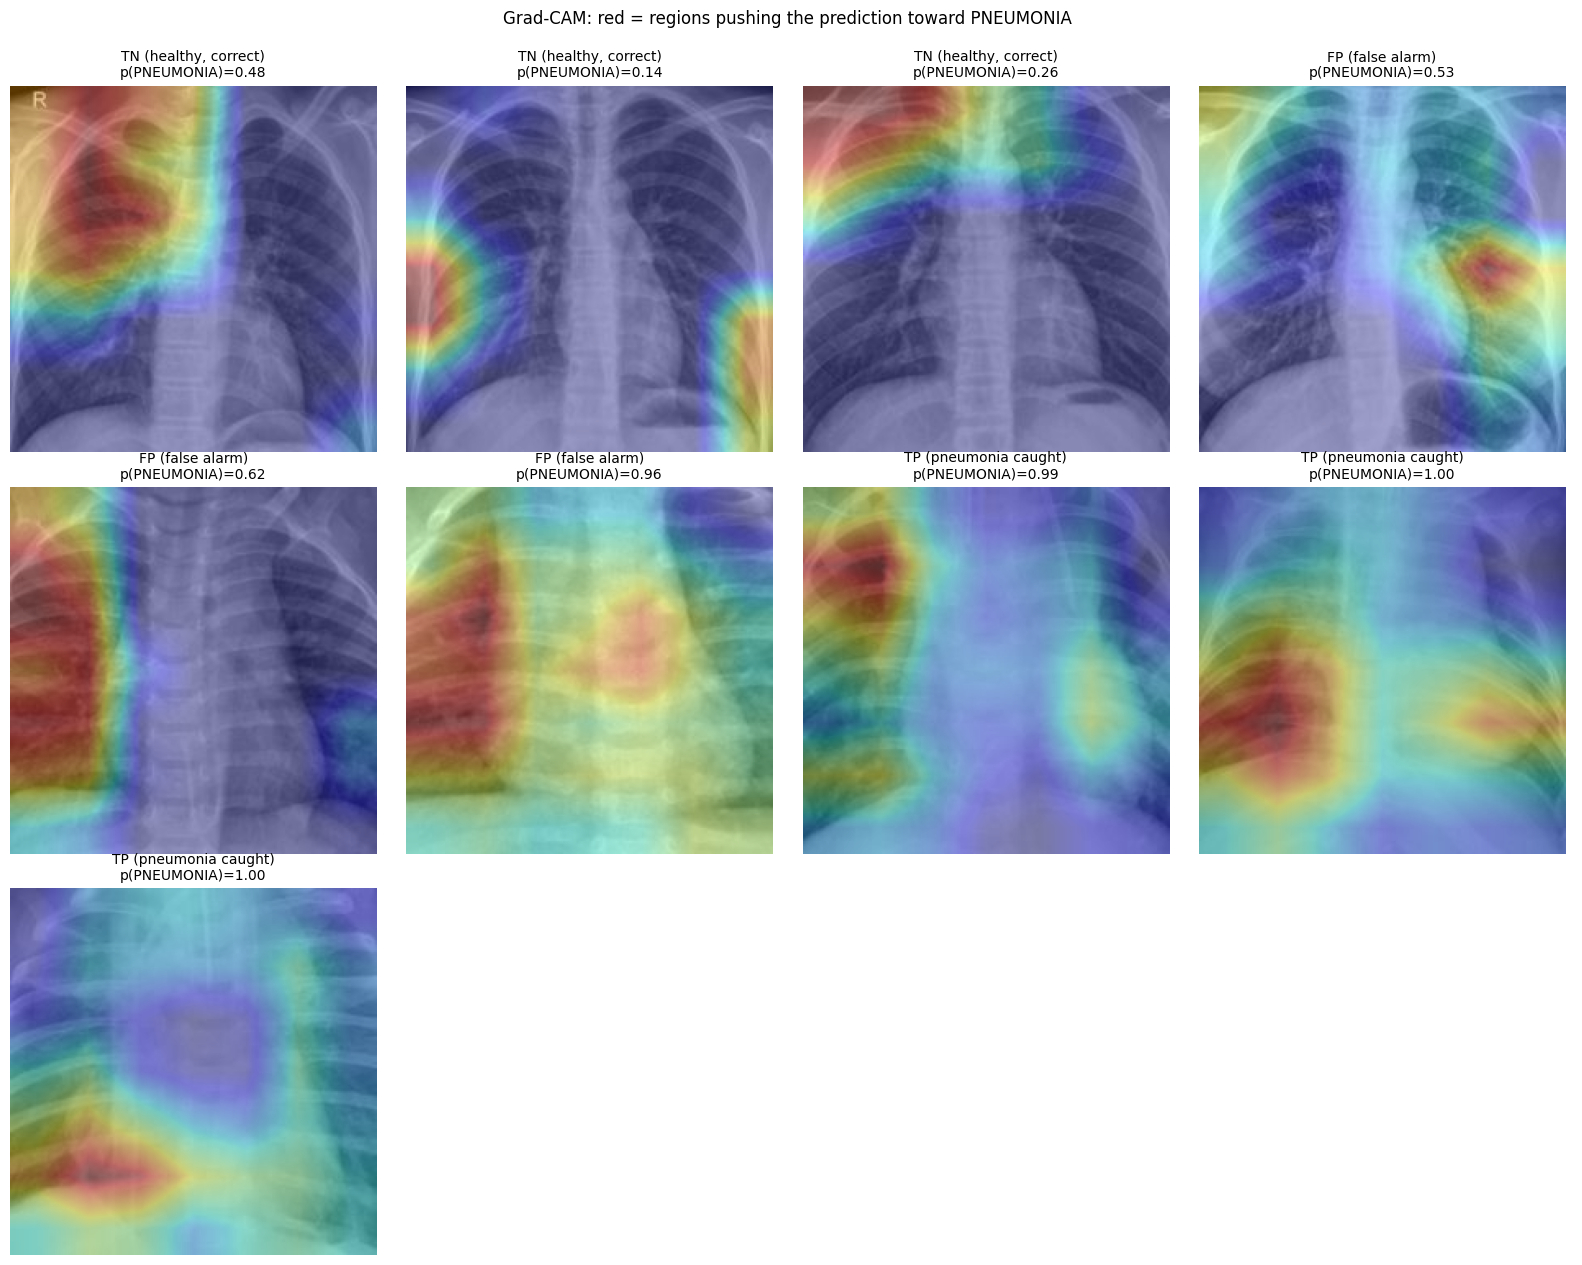

In [17]:
# 7b. Heatmaps for illustrative cases: hits, misses, and false alarms
# (the first three of each category by index — a deterministic, not random or
# representative, selection; step 13 later audits the full evaluation set instead)
# --------------------------------------------------------------------------
# test_loader yields a single, unshuffled batch, so indices into all_preds/all_labels
# line up directly with indices into test_dataset
pred_flat = all_preds.squeeze(1).int()
label_flat = all_labels.squeeze(1).int()

cases = {
    "TN (healthy, correct)":  [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 0],
    "FP (false alarm)":       [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 1],
    "TP (pneumonia caught)":  [i for i in range(len(label_flat)) if label_flat[i] == 1 and pred_flat[i] == 1],
    "FN (missed!)":           [i for i in range(len(label_flat)) if label_flat[i] == 1 and pred_flat[i] == 0],
}

selection = [(name, i) for name, idxs in cases.items() for i in idxs[:3]]

n_cols = 4
n_rows = -(-len(selection) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.2 * n_rows))
for ax, (name, idx) in zip(axes.flat, selection):
    img, label = test_dataset[idx]
    cam, p = grad_cam(resnet18, img)

    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.imshow(cam, cmap="jet", alpha=0.35)          # heatmap overlay
    ax.set_title(f"{name}\np(PNEUMONIA)={p:.2f}", fontsize=10)
    ax.axis("off")

for ax in axes.flat[len(selection):]:
    ax.axis("off")

fig.suptitle("Grad-CAM: red = regions pushing the prediction toward PNEUMONIA", y=1.0)
plt.tight_layout()
plt.show()

## 8. Model Persistence

`resnet18.state_dict()` on the full model captures **every** tensor — 11.7M parameters
× 4 bytes (float32) ≈ 45 MB — including the frozen backbone, which anyone can
reconstruct from torchvision. Saving only the head (`resnet18.fc.state_dict()`, 513
parameters) drops that to about 2 KB — a 20,000× reduction carrying the same trainable
information.

**There's a catch.** During training in `.train()` mode, the backbone's BatchNorm
layers kept updating their *running statistics* (mean/variance) from our X-rays, even
though `requires_grad=False` — gradient-freezing and statistic-freezing are two
different things. Those running statistics live in the backbone's `state_dict()`, not
the head's. So:
- the full checkpoint reproduces the evaluated model *given the same architecture,
  torchvision version, and pretrained-weights version* — "exactly" is doing some work
  in that sentence; a state_dict alone doesn't record any of those three,
- a fresh `make_model()` plus the head-only checkpoint reproduces a backbone with
  BatchNorm statistics from **ImageNet**, not from our data — predictions shift.

There's a second, larger consequence worth naming explicitly (not just for
persistence): this same BatchNorm-adaptation mechanism was active throughout *training*
too, in every step of this notebook. Step 5's batch-size change (150 → 8) altered not
only the number of gradient steps per epoch but also how often BatchNorm's running
statistics got updated — the two effects are entangled in every result this notebook
reports, not just here.

The cell below measures the persistence-time version of that shift on the
**validation** set (the evaluation set has already been used once, in step 6, and this
notebook no longer treats "once" as a reason to skip counting further uses — see step 6
and Conclusions). It also saves a small, deployment-oriented checkpoint that carries
the metadata a bare state_dict leaves out: class mapping, normalization constants,
decision threshold, and the exact pretrained-weights version used. The takeaway: a
model's "state" is not only its trainable weights — anything that influences the
forward pass counts, and anything needed to *reproduce* that forward pass belongs in
the checkpoint too.

In [18]:
# 8. Saving the head only, and measuring the BatchNorm gap
# -------------------------------------------------------------
torch.save(resnet18.fc.state_dict(), "models/pneumonia_head_only.pt")

for fname in ("resnet18_pneumonia_full_state.pt", "pneumonia_head_only.pt"):
    size = os.path.getsize(os.path.join("models", fname))
    print(f"models/{fname}: {size / 1e6:8.3f} MB")

# Reconstruction "from the head alone": fresh backbone (ImageNet BN stats) + our head
reconstructed = make_model()
reconstructed.fc.load_state_dict(torch.load("models/pneumonia_head_only.pt"))

full_loss, full_acc = evaluate_loss(resnet18, val_loader)       # original (BN fit to our data)
rec_loss, rec_acc = evaluate_loss(reconstructed, val_loader)    # reconstruction (BN from ImageNet)

print(f"\nValidation — full checkpoint:   loss {full_loss:.4f}, acc {full_acc:.3f}")
print(f"Validation — head-only reload:  loss {rec_loss:.4f}, acc {rec_acc:.3f}")
print("\nGiven identical code and environment, the gap above is due to BatchNorm")
print("running statistics — model state that lives outside fc. A different torchvision")
print("version or architecture tweak would reopen other gaps this comparison doesn't cover.")

# A deployment-oriented checkpoint: everything a bare state_dict leaves out
deployable_checkpoint = {
    "state_dict": resnet18.state_dict(),
    "architecture": "resnet18",
    "torchvision_weights": str(models.ResNet18_Weights.DEFAULT),
    "class_to_idx": train_dataset.classes,          # index -> class name, e.g. [NORMAL, PNEUMONIA]
    "transform_mean": transform_mean,
    "transform_std": transform_std,
    "input_size": 224,
    "decision_threshold": 0.5,                      # the untuned default this notebook reports at;
                                                      # see step 12 for why calibrating it needs care
}
torch.save(deployable_checkpoint, "models/resnet18_pneumonia_deployable.pt")
print("\nSaved models/resnet18_pneumonia_deployable.pt (state_dict + the metadata needed to use it)")

models/resnet18_pneumonia_full_state.pt:   44.788 MB
models/pneumonia_head_only.pt:    0.004 MB



Validation — full checkpoint:   loss 0.3123, acc 0.867
Validation — head-only reload:  loss 0.5528, acc 0.783

Given identical code and environment, the gap above is due to BatchNorm
running statistics — model state that lives outside fc. A different torchvision
version or architecture tweak would reopen other gaps this comparison doesn't cover.



Saved models/resnet18_pneumonia_deployable.pt (state_dict + the metadata needed to use it)


## 9. Testing a Hypothesis: Framing-Robust Augmentation

Step 7's Grad-CAM audit raised a specific, testable suspicion: a few false positives
showed heat concentrated near the image border rather than the lung fields.

**A correction on the claimed cause.** An earlier version of this notebook stated that
Kermany et al. (2018, *Cell*) document class-specific acquisition batches between
NORMAL and PNEUMONIA images. Re-checking the paper directly: it documents
anterior-posterior radiographs from a single center (Guangzhou), collected during
routine clinical care and quality-screened before grading — it does **not** describe
class-specific acquisition differences or differential imaging of sicker patients. That
claim traced back to an informal, unverified recollection, not a sourced fact, and has
been removed everywhere else in this notebook. What's left, stated at the strength it
actually supports: *qualitative inspection suggested class-associated framing
differences in this subset* — a hypothesis worth testing, not a documented mechanism.
Step 13 later measures the pattern quantitatively across the full evaluation set,
rather than resting on this claim or on four hand-picked images.

If the model is partly reading *how the image was framed* rather than the disease
itself, training it to be **invariant to plausible framing variation** should weaken
that shortcut — ideally trading it for more reliance on the actual opacity pattern.

We test this by changing one thing from step 5's protocol: same architecture, same
optimizer and learning rate, same batch size, same 25-epoch budget with
validation-based checkpoint selection, and — from this step onward — the same random
seed reset immediately before model creation, so this and step 5's model at least start
from comparable initializations (earlier versions of steps 9–11 skipped this, so their
compared models differed in random head initialization too, not just the studied
variable — see Conclusions, limitation 4). **What a single seed-matched run can and
can't show:** matching the seed removes one confound, but this is still one run of one
variant — CPU floating-point non-determinism and ordinary batch-order effects are not
controlled by seed-matching alone. Read anything below as *a single exploratory
observation*, not a proven, repeatable effect — that would need several seeds, reported
as a mean ± spread, which this notebook doesn't run here.

**Augmentation choices, and why domain knowledge constrains them:**
- `RandomResizedCrop(224, scale=(0.8, 1.0))` and `RandomAffine(degrees=5,
  translate=(0.05, 0.05))` are applied together — two transformations at once, so their
  *individual* contributions aren't separated by this experiment either.
  `RandomResizedCrop`'s default `ratio=(0.75, 1.33)` can also stretch the image
  non-uniformly when resizing back to square, which risks distorting anatomy; step 9a
  now includes a visual check rather than assuming this is benign.
- Chlap et al. (2021, *Journal of Medical Imaging and Radiation Oncology*,
  65(5):545-563) make the point this notebook follows throughout: augmentation for
  medical images should be restricted to transformations that remain **clinically
  plausible**, not applied wholesale from a generic computer-vision augmentation
  library.
- **Deliberately no horizontal flip.** Mirroring a chest X-ray moves the cardiac
  silhouette and aortic knob to the anatomically wrong side — the imaging appearance of
  *situs inversus*, a real (if rare) congenital condition, not a harmless photometric
  perturbation. Radiopaedia's teaching case ["Situs inversus on flipped and incorrectly
  labeled chest
  x-ray"](https://radiopaedia.org/cases/situs-inversus-on-flipped-and-incorrectly-labelled-chest-x-ray)
  shows a real clinical image that was mirrored and briefly mistaken for exactly this
  condition, and Filice & Frantz (2019, *Journal of Digital Imaging*, 32(4):656-664)
  built a deep-learning classifier specifically to catch left/right laterality errors
  in radiographs — evidence that laterality is treated as clinically load-bearing
  information in this field, not noise a model should be trained to ignore.
- Validation and evaluation-set transforms are **untouched** — augmentation only ever
  applies to `train_loader_aug`.

augmented train loader: 240 images, 30 steps/epoch


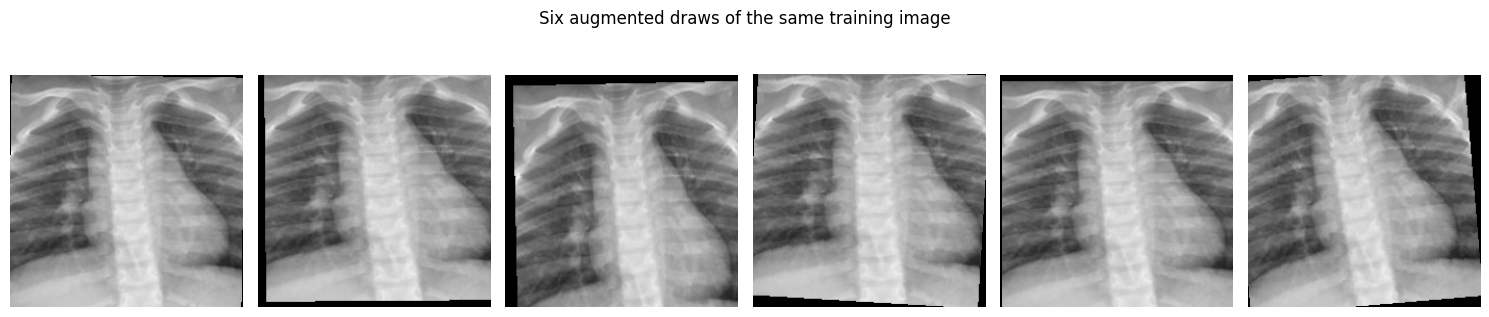

In [19]:
# 9a. Augmented training transform, applied only to the training split
# -------------------------------------------------------------------------
augment_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=transform_mean, std=transform_std),
])

# A second ImageFolder over the same files, differing only in transform —
# reusing train_idx from step 5a keeps the split identical
train_dataset_aug = ImageFolder('data/chestxrays/train', transform=augment_transform)
train_subset_aug = Subset(train_dataset_aug, train_idx)
train_loader_aug = DataLoader(train_subset_aug, batch_size=8, shuffle=True)

print(f"augmented train loader: {len(train_subset_aug)} images, "
      f"{len(train_loader_aug)} steps/epoch")

# Visual check, not just an assumption: does RandomResizedCrop's default
# ratio=(0.75, 1.33) visibly distort anatomy when it resizes back to square?
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for ax in axes:
    img, label = train_dataset_aug[0]  # same source image, six independent augmentation draws
    ax.imshow(denormalize(img).permute(1, 2, 0))
    ax.axis("off")
fig.suptitle("Six augmented draws of the same training image", y=1.05)
plt.tight_layout()
plt.show()

In [20]:
# 9b. Retraining under a matched protocol — same seed reset as step 5's model, so
# the compared pair at least starts from the same initialization. The training-data
# augmentation is the intended difference; a single run like this can't fully
# isolate its effect (see the note above and Conclusions, limitation 4).
# -------------------------------------------------------------------------
torch.manual_seed(101010)
np.random.seed(101010)
resnet18_aug = make_model()
optimizer_aug = optim.Adam(resnet18_aug.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss_aug = float("inf")
best_state_aug = None
best_epoch_aug = -1

for epoch in range(num_epochs):
    resnet18_aug.train()
    for inputs, labels in train_loader_aug:
        labels = labels.float().unsqueeze(1)
        optimizer_aug.zero_grad()
        loss = criterion(resnet18_aug(inputs), labels)
        loss.backward()
        optimizer_aug.step()

    # Train-loss readout uses the *unaugmented* loader (train_loader_s) so it's
    # directly comparable to step 5b's numbers, instead of scoring against a
    # freshly re-randomized crop every epoch
    train_loss, train_acc = evaluate_loss(resnet18_aug, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18_aug, val_loader)

    marker = ""
    if val_loss < best_val_loss_aug:
        best_val_loss_aug = val_loss
        best_state_aug = copy.deepcopy(resnet18_aug.state_dict())
        best_epoch_aug = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_aug.load_state_dict(best_state_aug)
print(f"\nRestored weights from epoch {best_epoch_aug} (val loss {best_val_loss_aug:.4f})")

Epoch  1/25  train: 0.6963 (acc 0.546)  val: 0.6580 (acc 0.583)  <- best so far


Epoch  2/25  train: 0.5161 (acc 0.754)  val: 0.5339 (acc 0.683)  <- best so far


Epoch  3/25  train: 0.4613 (acc 0.758)  val: 0.4861 (acc 0.783)  <- best so far


Epoch  4/25  train: 0.5524 (acc 0.692)  val: 0.5991 (acc 0.683)


Epoch  5/25  train: 0.3976 (acc 0.838)  val: 0.4282 (acc 0.867)  <- best so far


...

Epoch 21/25  train: 0.4156 (acc 0.800)  val: 0.5670 (acc 0.833)


Epoch 22/25  train: 0.5398 (acc 0.750)  val: 0.7039 (acc 0.717)


Epoch 23/25  train: 0.5035 (acc 0.754)  val: 0.6813 (acc 0.717)


Epoch 24/25  train: 0.3831 (acc 0.821)  val: 0.5305 (acc 0.850)


Epoch 25/25  train: 0.3321 (acc 0.838)  val: 0.4844 (acc 0.867)

Restored weights from epoch 9 (val loss 0.4246)


### Evaluating the augmented model (test set, second and last disclosed look)

Same provided evaluation pattern as steps 3 and 6, run against `resnet18_aug`.

In [21]:
# 9c. Evaluate the augmented model, and compare to step 6 side by side
# -------------------------------------------------------------------------
model = resnet18_aug
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_aug, all_labels_aug = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_aug.extend(preds.tolist())
        all_labels_aug.extend(labels.unsqueeze(1).tolist())

# Converted once, after the loop — the provided-code pattern in steps 3/6 converts
# inside the loop, which only works because test_loader happens to yield a single
# batch; doing it once here avoids depending on that fragile quirk
all_preds_aug = torch.tensor(all_preds_aug)
all_labels_aug = torch.tensor(all_labels_aug)
test_acc_aug = accuracy_metric(all_preds_aug, all_labels_aug).item()
test_f1_aug = f1_metric(all_preds_aug, all_labels_aug).item()

print("Without framing augmentation (step 6):")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nWith framing augmentation (step 9):")
augmented_report = confusion_report(all_preds_aug, all_labels_aug, test_acc_aug, test_f1_aug)

Without framing augmentation (step 6):
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

With framing augmentation (step 9):
Accuracy: 0.800   F1: 0.783

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 44          FP=  6
actual PNEUMONIA:      FN= 14          TP= 36

Sensitivity (recall): 0.720  <- fraction of sick patients detected
Specificity:          0.880  <- fraction of healthy patients correctly cleared
Precision:            0.857  <- fraction of alarms that were correct

Missed cases (FN): 14 of 50 pneumonia patients


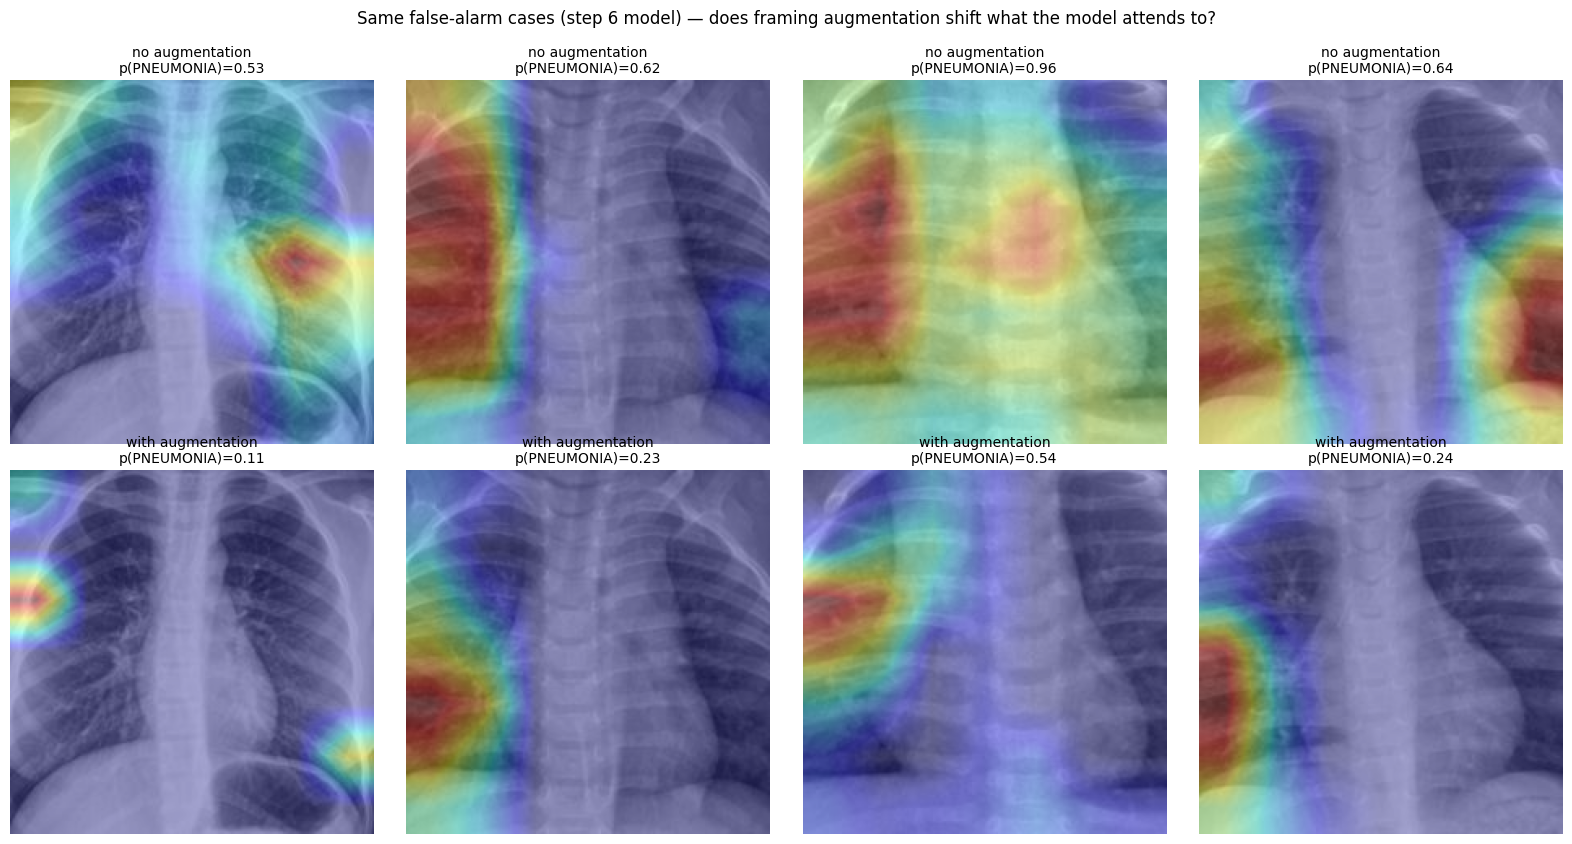

In [22]:
# 9d. Grad-CAM, before vs. after augmentation, on the original model's false alarms
# -----------------------------------------------------------------------------------
fp_idx = [i for i in range(len(label_flat)) if label_flat[i] == 0 and pred_flat[i] == 1][:4]

fig, axes = plt.subplots(2, len(fp_idx), figsize=(4 * len(fp_idx), 8.4))
for col, idx in enumerate(fp_idx):
    img, label = test_dataset[idx]

    cam0, p0 = grad_cam(resnet18, img)
    axes[0, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[0, col].imshow(cam0, cmap="jet", alpha=0.35)
    axes[0, col].set_title(f"no augmentation\np(PNEUMONIA)={p0:.2f}", fontsize=10)
    axes[0, col].axis("off")

    cam1, p1 = grad_cam(resnet18_aug, img)
    axes[1, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[1, col].imshow(cam1, cmap="jet", alpha=0.35)
    axes[1, col].set_title(f"with augmentation\np(PNEUMONIA)={p1:.2f}", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Same false-alarm cases (step 6 model) — does framing augmentation shift what the model attends to?", y=1.0)
plt.tight_layout()
plt.show()

### What we learned

The result is mixed, and more interesting for being mixed — an honest experiment beats
a cherry-picked one. (This compares two single, seed-matched runs — read every claim
below as an observation from *this run*, not a proven effect.)

**In favor of the shortcut hypothesis:** framing augmentation cut false positives from
24 to 6 (a 75% reduction) and raised specificity from 0.52 to 0.88. Across the four
false-alarm cases visualized above, the augmented model's predicted PNEUMONIA score
dropped substantially on every single one (0.53→0.11, 0.62→0.23, 0.96→0.54, 0.64→0.24)
— three of the four now cross below the 0.5 threshold, the fourth (formerly the most
confident false alarm) moved much closer to it. That's consistent with step 7's
suspicion: at least part of what the original model treated as evidence for PNEUMONIA
was associated with framing, and training away framing sensitivity took much of it
with it.

**Against a clean win:**
- **Sensitivity fell**: 1.00 → 0.72. The augmented model now misses 14 of 50 pneumonia
  cases, versus 0 before. Accuracy actually *improved* (0.76 → 0.80) and F1 fell only
  slightly (0.81 → 0.78) — a much less lopsided trade than a purely sensitivity-vs-
  specificity framing would suggest, but still a real cost on the metric that matters
  most for a screening-style use case.
- **The Grad-CAM maps show a genuinely mixed picture.** Some heatmaps clearly relocate
  (the first case moves from a right-lung hotspot to a left-upper-field one); others
  stay roughly in the same region while the score simply drops. Step 7's caveat applies
  here too: Grad-CAM is circumstantial evidence, not proof.
- **Optimization was noisier than step 5/6's**, though not catastrophically so: the
  best checkpoint came from epoch **9/25** (val loss 0.4246, val acc 0.867), well
  short of step 5/6's val loss (0.3123) and with visible oscillation (val loss ranged
  roughly 0.42–0.80 across the run) rather than a smooth descent.

**One more thing the visual check above (step 9a) makes hard to miss:**
`RandomAffine`'s default `fill=0` paints rotated corners black — visible as sharp black
wedges in several of the six augmented draws shown. That's a second artificial-edge
problem, similar in spirit to the reason step 15 uses mid-gray instead of black for its
mask: a crisp black wedge is a very salient, easy-to-detect feature, and there's no
principled reason to believe the model ignores it just because it wasn't the point of
the transform. A better version of this experiment would set `fill=` to the dataset
mean instead of leaving it at the default.

**Verdict:** this model is *not* adopted — the checkpoints saved in step 8 remain the
step 5/6 model. The experiment stays in the notebook regardless of outcome: a result
from a single, seed-matched, one-variable-changed run is still informative about *how*
the shortcut might operate, even though it doesn't prove a mechanism (Conclusions,
limitation 4).

**A note on why these numbers differ from an earlier version of this notebook:** this
exact experiment previously reported accuracy 0.71 (not 0.80) and a much more severe
sensitivity collapse (to 0.52, not 0.72) — from a run with an unseeded, order-dependent
random head initialization (Conclusions, limitation 4). Same code, same hypothesis,
different random draw, meaningfully different story. That swing is itself the
strongest evidence in this notebook for why single, unseeded runs shouldn't be
over-interpreted.

## 10. Deeper Fine-Tuning: Unfreezing `layer4`

Step 2 froze the entire backbone on purpose: 300 training images is nowhere near
enough to fine-tune 11.7M parameters without overfitting almost immediately. But the
513-parameter head sits at the opposite extreme — very little capacity to adapt
ImageNet features toward chest-X-ray-specific patterns. `layer4`, the last residual
block, is a natural middle ground: ResNet's earlier stages learn generic,
broadly-transferable features (edges, textures, gradients), while its later stages
assemble those into increasingly abstract, *task-specific* representations. Unfreezing
just the last block lets those most task-specific pretrained features adapt, while
`layer1`–`layer3` stay frozen as general-purpose feature extractors.

**Differential learning rates matter here.** The backbone already encodes genuinely
useful pretrained weights; applying the head's learning rate (0.001) to them would
overwrite that in a handful of steps, before the small 240-image training signal could
guide it anywhere useful. The standard fix — giving newly-initialized layers a normal
learning rate and pretrained layers a much smaller one — is used here too: **0.001 for
the head, 0.0001 for `layer4`** (10× smaller).

Everything else matches step 5's protocol, including — from this step onward — a seed
reset immediately before model creation (see step 9's note on why, and Conclusions,
limitation 4, on what seed-matching does and doesn't fix): no augmentation (step 9's
augmentation is a separate, orthogonal experiment), same batch size (8), same 25-epoch
budget with validation-loss checkpointing. This changes one *studied* variable relative
to step 5/6; it is still a single run, not a controlled, repeated experiment.

**On the evaluation set:** this is the third model (after step 9) compared against
step 6's on the same, already-repeatedly-used evaluation set (see step 6's note on why
this notebook no longer calls that set "observed once").

In [23]:
# 10a. Unfreeze layer4 only; differential learning rates via optimizer param groups
# -----------------------------------------------------------------------------------
torch.manual_seed(101010)
np.random.seed(101010)
resnet18_deep = make_model()
for p in resnet18_deep.layer4.parameters():
    p.requires_grad = True

trainable_deep = sum(p.numel() for p in resnet18_deep.parameters() if p.requires_grad)
total_deep = sum(p.numel() for p in resnet18_deep.parameters())
print(f"Trainable parameters: {trainable_deep:,} of {total_deep:,} "
      f"({100 * trainable_deep / total_deep:.2f}%)")

optimizer_deep = optim.Adam([
    {"params": resnet18_deep.fc.parameters(), "lr": 0.001},
    {"params": resnet18_deep.layer4.parameters(), "lr": 0.0001},
])

Trainable parameters: 8,394,241 of 11,177,025 (75.10%)


In [24]:
# 10b. Training with layer4 unfrozen — otherwise identical to step 5b
# -------------------------------------------------------------------------
num_epochs = 25
best_val_loss_deep = float("inf")
best_state_deep = None
best_epoch_deep = -1

for epoch in range(num_epochs):
    resnet18_deep.train()
    for inputs, labels in train_loader_s:
        labels = labels.float().unsqueeze(1)
        optimizer_deep.zero_grad()
        loss = criterion(resnet18_deep(inputs), labels)
        loss.backward()
        optimizer_deep.step()

    train_loss, train_acc = evaluate_loss(resnet18_deep, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18_deep, val_loader)

    marker = ""
    if val_loss < best_val_loss_deep:
        best_val_loss_deep = val_loss
        best_state_deep = copy.deepcopy(resnet18_deep.state_dict())
        best_epoch_deep = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_deep.load_state_dict(best_state_deep)
print(f"\nRestored weights from epoch {best_epoch_deep} (val loss {best_val_loss_deep:.4f})")

Epoch  1/25  train: 0.5463 (acc 0.700)  val: 0.7002 (acc 0.617)  <- best so far


Epoch  2/25  train: 0.0370 (acc 0.979)  val: 0.2617 (acc 0.883)  <- best so far


Epoch  3/25  train: 0.0039 (acc 1.000)  val: 0.2043 (acc 0.917)  <- best so far


Epoch  4/25  train: 0.0021 (acc 1.000)  val: 0.2767 (acc 0.917)


Epoch  5/25  train: 0.0018 (acc 1.000)  val: 0.3671 (acc 0.917)


...

Epoch 21/25  train: 0.0070 (acc 0.996)  val: 0.2214 (acc 0.933)


Epoch 22/25  train: 0.0039 (acc 0.996)  val: 0.2918 (acc 0.917)


Epoch 23/25  train: 0.0003 (acc 1.000)  val: 0.2957 (acc 0.933)


Epoch 24/25  train: 0.0003 (acc 1.000)  val: 0.2451 (acc 0.933)


Epoch 25/25  train: 0.0002 (acc 1.000)  val: 0.3539 (acc 0.933)

Restored weights from epoch 3 (val loss 0.2043)


### Evaluating the deeper fine-tuned model (test set, third and last disclosed look)

In [25]:
# 10c. Evaluate the deeper fine-tuned model, and compare to step 6 and step 9
# -------------------------------------------------------------------------
model = resnet18_deep
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_deep, all_labels_deep = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_deep.extend(preds.tolist())
        all_labels_deep.extend(labels.unsqueeze(1).tolist())

all_preds_deep = torch.tensor(all_preds_deep)
all_labels_deep = torch.tensor(all_labels_deep)
test_acc_deep = accuracy_metric(all_preds_deep, all_labels_deep).item()
test_f1_deep = f1_metric(all_preds_deep, all_labels_deep).item()

print("Step 6 — frozen backbone, no augmentation:")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nStep 9 — frozen backbone, framing augmentation:")
_ = confusion_report(all_preds_aug, all_labels_aug, test_acc_aug, test_f1_aug)
print("\nStep 10 — layer4 unfrozen, no augmentation:")
deep_report = confusion_report(all_preds_deep, all_labels_deep, test_acc_deep, test_f1_deep)

Step 6 — frozen backbone, no augmentation:
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

Step 9 — frozen backbone, framing augmentation:
Accuracy: 0.800   F1: 0.783

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 44          FP=  6
actual PNEUMONIA:      FN= 14          TP= 36

Sensitivity (recall): 0.720  <- fraction of sick patients detected
Specificity:          0.880  <- fraction of healthy patients correctly cleared
Precision:            0.857  <- fraction of alarms that were correct

Missed cases (FN): 14 of 50 pneumonia patients

Step 10 — layer4 unfrozen, no augmentati

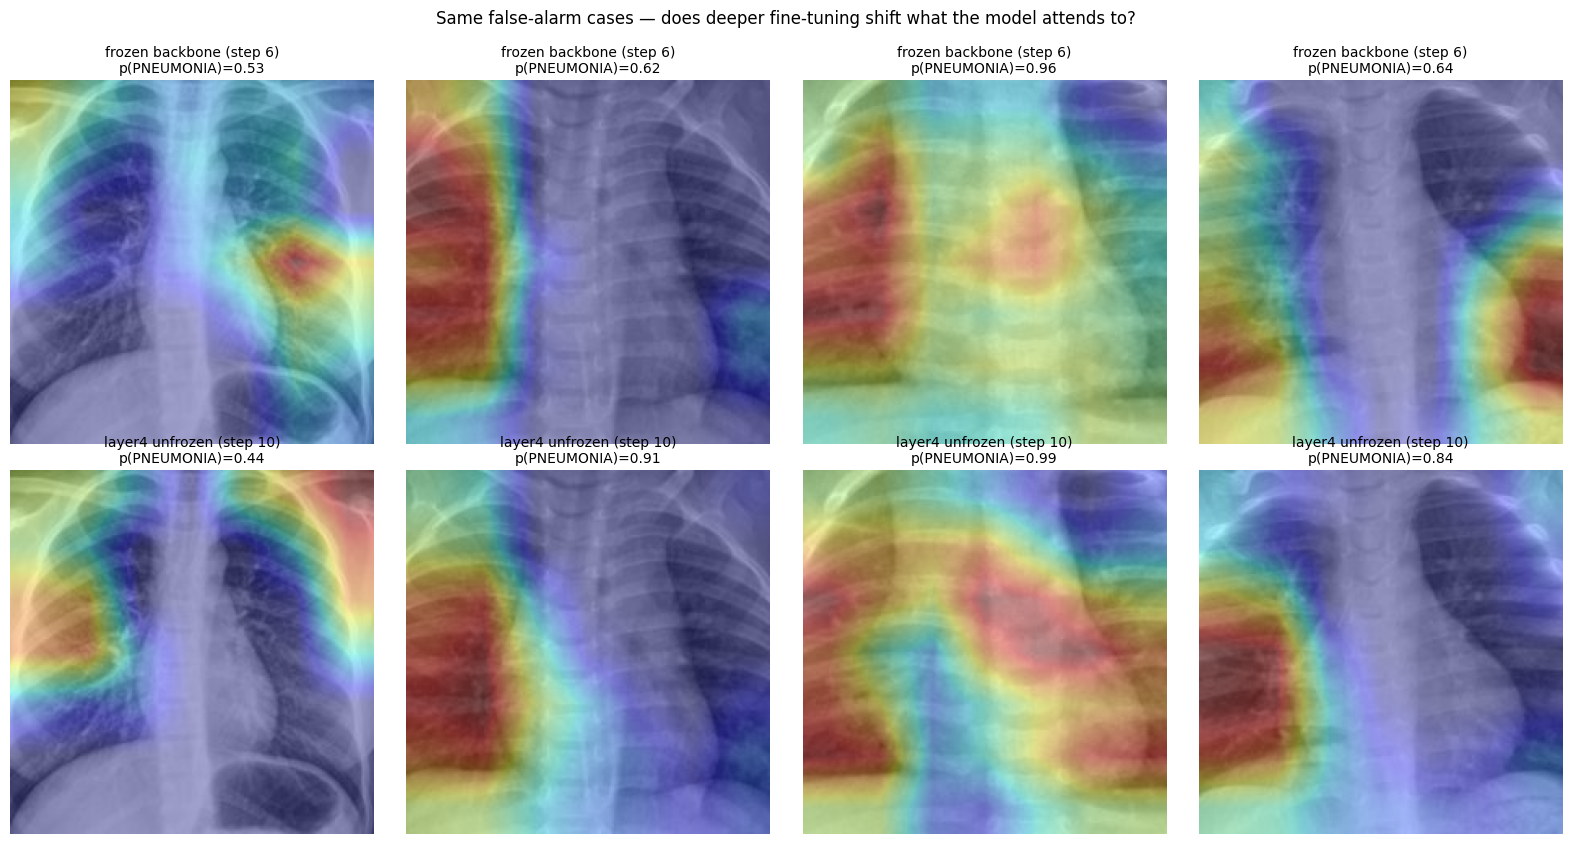

In [26]:
# 10d. Grad-CAM, frozen vs. layer4-unfrozen, on the same false-alarm cases as step 9
# -----------------------------------------------------------------------------------
fig, axes = plt.subplots(2, len(fp_idx), figsize=(4 * len(fp_idx), 8.4))
for col, idx in enumerate(fp_idx):
    img, label = test_dataset[idx]

    cam0, p0 = grad_cam(resnet18, img)
    axes[0, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[0, col].imshow(cam0, cmap="jet", alpha=0.35)
    axes[0, col].set_title(f"frozen backbone (step 6)\np(PNEUMONIA)={p0:.2f}", fontsize=10)
    axes[0, col].axis("off")

    cam1, p1 = grad_cam(resnet18_deep, img)
    axes[1, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[1, col].imshow(cam1, cmap="jet", alpha=0.35)
    axes[1, col].set_title(f"layer4 unfrozen (step 10)\np(PNEUMONIA)={p1:.2f}", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Same false-alarm cases — does deeper fine-tuning shift what the model attends to?", y=1.0)
plt.tight_layout()
plt.show()

### What we learned

**Overfitting, clearly — and consistently.** 8,394,241 of 11,177,025 parameters
(75.1%) were trainable here. Even with a 10× smaller learning rate on `layer4`, the
model memorized the 240 training images almost immediately: train loss fell to under
0.01 and train accuracy hit 1.000 by epoch 3–4, and mostly stayed there. The best
checkpoint came from **epoch 3 of 25** (val loss 0.2043); the remaining 22 epochs
oscillated (val loss ranging roughly 0.20–0.58) without reliably beating it.

**This time, that overfitting came with a real aggregate benefit.** Accuracy 0.810,
F1 0.840, sensitivity 1.000 (unchanged, still 0/50 missed), specificity 0.620 (up from
step 6's 0.520, FP down from 24 to 19). This is a clear win over step 6 on every metric
— not a tie, and not a wash.

**That's a materially different outcome than this same experiment produced before —
and the reason why is the point of this section.** An earlier version of this notebook
ran this exact code, unseeded, and got a **numerically identical confusion matrix to
step 6** (TN=26, FP=24, FN=0, TP=50 — the same severe-overfitting training dynamics,
different specific weights, coincidentally the same aggregate result), which that
version discussed at length as "an identical-looking tie hiding redistributed
individual errors." That framing is no longer accurate for *this* run — but it wasn't
wrong about the mechanism: it's the same failure mode (severe, fast overfitting to a
513-times-larger parameter budget than the 240-image training set can really support)
producing a *different specific outcome* purely because of which random numbers the
head's initial weights happened to draw (Conclusions, limitation 4). Looking at the
same four false-alarm cases from step 6: this run's model pushes three of them to even
*higher* PNEUMONIA scores (0.62→0.91, 0.96→0.99, 0.64→0.84) and only flips the weakest
one (0.53→0.44) — a different specific pattern than either the tie-producing run or
step 9's augmented model showed on the same four images.

**Verdict:** despite the better aggregate numbers, this model is **not adopted**. One
seed-matched run that happens to land well is not evidence the recipe is reliable —
if anything, the fact that an earlier run of the *identical code* landed on a flatly
different outcome is direct evidence that it isn't, yet. The severe overfitting
(train accuracy 1.000 by epoch 3–4 in both runs) is the part of this result worth
trusting; the specific test-set number it happened to produce is not, without several
more seeds to see how much it actually varies.

## 11. Completing the 2×2: Augmentation × Deeper Fine-Tuning

Steps 6, 9, and 10 form three corners of a 2×2 grid varying two levers: **training-data
diversity** (plain vs. framing-augmented) and **trainable capacity** (head-only vs.
`layer4` unfrozen). The fourth corner — augmented data *with* `layer4` unfrozen —
hasn't been tried, and it's arguably the most interesting one to look at:

- Step 9 (augmented data, head-only) showed signs that 513 parameters may not have had
  enough capacity to fully exploit the harder, augmented training distribution —
  validation loss got noisy early and never improved past epoch 3.
- Step 10 (plain data, `layer4` unfrozen) showed the opposite problem: plenty of spare
  capacity, but only 240 raw images to point it at, so it memorized them almost
  immediately instead of learning anything more general.

Augmentation increases the *diversity* the training data presents on each pass. Giving
the extra `layer4` capacity from step 10 that harder signal, instead of the same 240
raw images repeated every epoch, is worth trying — but whether these two weaknesses
actually offset each other is exactly what a single run below can suggest, not settle:
this is one more seed-matched, one-run comparison (same caveats as steps 9 and 10;
Conclusions, limitation 4), not a controlled test of an interaction effect. Protocol:
identical to steps 9 and 10 — `train_loader_aug`, `layer4` unfrozen, the same
differential learning rates (0.001 head / 0.0001 `layer4`), same batch size, same
25-epoch budget with validation-based checkpointing, seed reset before model creation.

This is also the fourth model compared against step 6's result on the same,
repeatedly-used evaluation set (after steps 9 and 10).

In [27]:
# 11a. layer4 unfrozen + framing augmentation — the fourth cell of the 2x2 grid
# -------------------------------------------------------------------------
torch.manual_seed(101010)
np.random.seed(101010)
resnet18_combo = make_model()
for p in resnet18_combo.layer4.parameters():
    p.requires_grad = True

optimizer_combo = optim.Adam([
    {"params": resnet18_combo.fc.parameters(), "lr": 0.001},
    {"params": resnet18_combo.layer4.parameters(), "lr": 0.0001},
])

In [28]:
# 11b. Training: augmented inputs, layer4 unfrozen — otherwise identical protocol
# -------------------------------------------------------------------------
num_epochs = 25
best_val_loss_combo = float("inf")
best_state_combo = None
best_epoch_combo = -1

for epoch in range(num_epochs):
    resnet18_combo.train()
    for inputs, labels in train_loader_aug:
        labels = labels.float().unsqueeze(1)
        optimizer_combo.zero_grad()
        loss = criterion(resnet18_combo(inputs), labels)
        loss.backward()
        optimizer_combo.step()

    # Train-loss readout uses the unaugmented loader, as in steps 9b/10b, so all
    # four experiments' printed "train" numbers stay directly comparable
    train_loss, train_acc = evaluate_loss(resnet18_combo, train_loader_s)
    val_loss, val_acc = evaluate_loss(resnet18_combo, val_loader)

    marker = ""
    if val_loss < best_val_loss_combo:
        best_val_loss_combo = val_loss
        best_state_combo = copy.deepcopy(resnet18_combo.state_dict())
        best_epoch_combo = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_combo.load_state_dict(best_state_combo)
print(f"\nRestored weights from epoch {best_epoch_combo} (val loss {best_val_loss_combo:.4f})")

Epoch  1/25  train: 0.2490 (acc 0.917)  val: 0.3051 (acc 0.900)  <- best so far


Epoch  2/25  train: 0.1387 (acc 0.946)  val: 0.3963 (acc 0.900)


Epoch  3/25  train: 0.1158 (acc 0.942)  val: 0.4241 (acc 0.867)


Epoch  4/25  train: 0.2068 (acc 0.908)  val: 0.5160 (acc 0.917)


Epoch  5/25  train: 0.3051 (acc 0.883)  val: 0.9842 (acc 0.817)


...

Epoch 21/25  train: 0.0692 (acc 0.971)  val: 0.8784 (acc 0.883)


Epoch 22/25  train: 0.0345 (acc 0.988)  val: 0.7937 (acc 0.883)


Epoch 23/25  train: 0.0088 (acc 1.000)  val: 0.7614 (acc 0.900)


Epoch 24/25  train: 0.0084 (acc 0.996)  val: 0.8472 (acc 0.900)


Epoch 25/25  train: 0.0183 (acc 0.996)  val: 0.7438 (acc 0.900)

Restored weights from epoch 13 (val loss 0.2945)


### Evaluating the combined model (test set, fourth and last disclosed look)

In [29]:
# 11c. Evaluate the combined model — all four corners of the 2x2 grid, side by side
# -------------------------------------------------------------------------
model = resnet18_combo
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_combo, all_labels_combo = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_combo.extend(preds.tolist())
        all_labels_combo.extend(labels.unsqueeze(1).tolist())

all_preds_combo = torch.tensor(all_preds_combo)
all_labels_combo = torch.tensor(all_labels_combo)
test_acc_combo = accuracy_metric(all_preds_combo, all_labels_combo).item()
test_f1_combo = f1_metric(all_preds_combo, all_labels_combo).item()

print("Step  6 — frozen backbone, no augmentation:")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nStep  9 — frozen backbone, framing augmentation:")
_ = confusion_report(all_preds_aug, all_labels_aug, test_acc_aug, test_f1_aug)
print("\nStep 10 — layer4 unfrozen, no augmentation:")
_ = confusion_report(all_preds_deep, all_labels_deep, test_acc_deep, test_f1_deep)
print("\nStep 11 — layer4 unfrozen, framing augmentation:")
combo_report = confusion_report(all_preds_combo, all_labels_combo, test_acc_combo, test_f1_combo)

Step  6 — frozen backbone, no augmentation:
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

Step  9 — frozen backbone, framing augmentation:
Accuracy: 0.800   F1: 0.783

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 44          FP=  6
actual PNEUMONIA:      FN= 14          TP= 36

Sensitivity (recall): 0.720  <- fraction of sick patients detected
Specificity:          0.880  <- fraction of healthy patients correctly cleared
Precision:            0.857  <- fraction of alarms that were correct

Missed cases (FN): 14 of 50 pneumonia patients

Step 10 — layer4 unfrozen, no augmenta

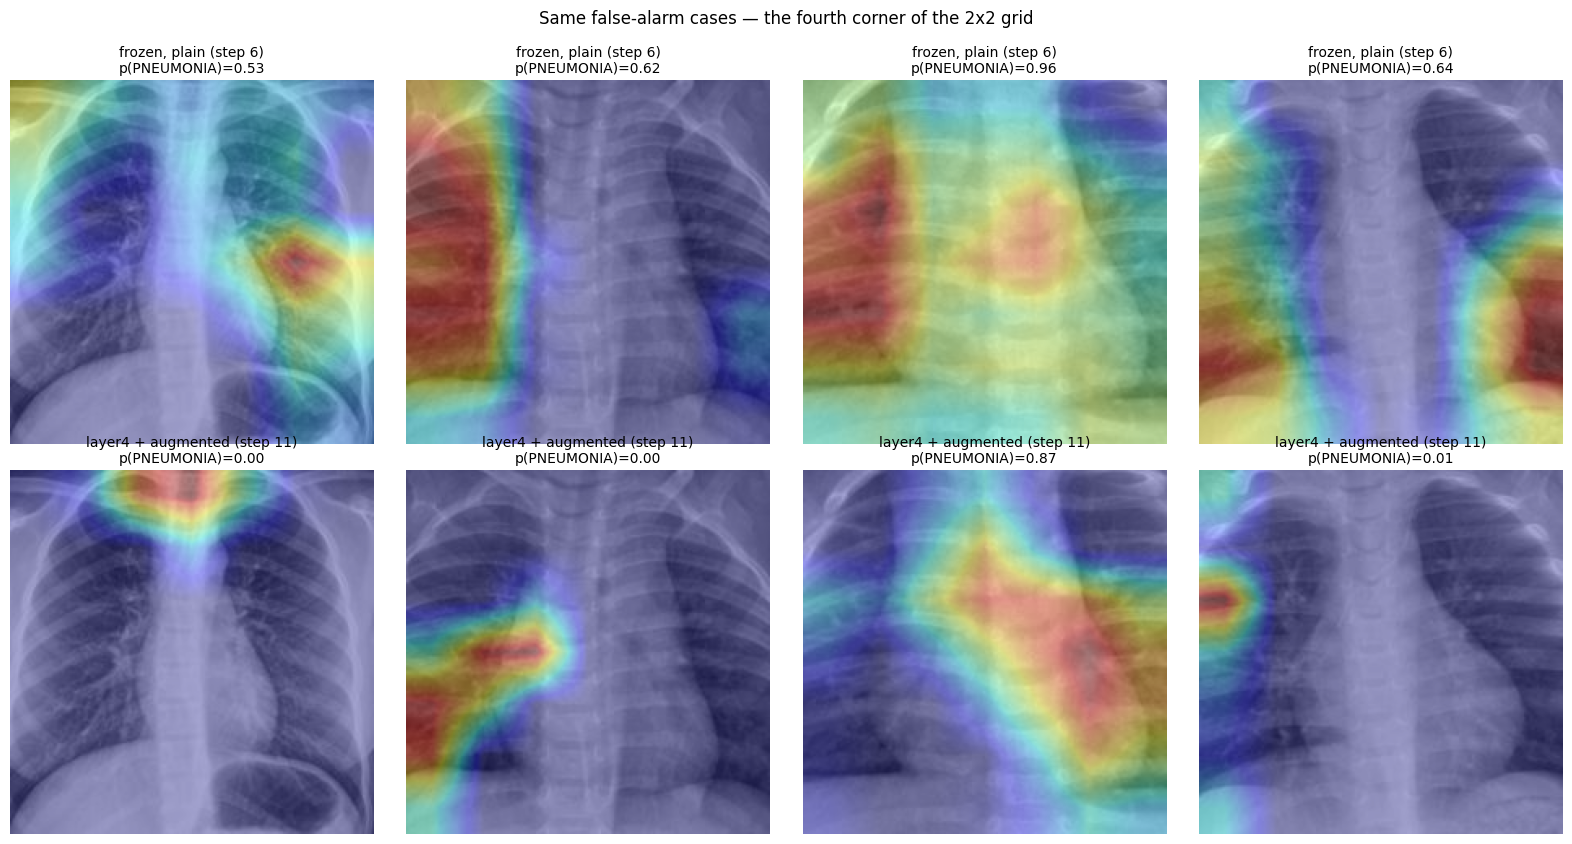

In [30]:
# 11d. Grad-CAM, frozen-plain (step 6) vs. layer4-unfrozen + augmented (step 11)
# -----------------------------------------------------------------------------------
fig, axes = plt.subplots(2, len(fp_idx), figsize=(4 * len(fp_idx), 8.4))
for col, idx in enumerate(fp_idx):
    img, label = test_dataset[idx]

    cam0, p0 = grad_cam(resnet18, img)
    axes[0, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[0, col].imshow(cam0, cmap="jet", alpha=0.35)
    axes[0, col].set_title(f"frozen, plain (step 6)\np(PNEUMONIA)={p0:.2f}", fontsize=10)
    axes[0, col].axis("off")

    cam1, p1 = grad_cam(resnet18_combo, img)
    axes[1, col].imshow(denormalize(img).permute(1, 2, 0))
    axes[1, col].imshow(cam1, cmap="jet", alpha=0.35)
    axes[1, col].set_title(f"layer4 + augmented (step 11)\np(PNEUMONIA)={p1:.2f}", fontsize=10)
    axes[1, col].axis("off")

fig.suptitle("Same false-alarm cases — the fourth corner of the 2x2 grid", y=1.0)
plt.tight_layout()
plt.show()

### What we learned

**The best raw numbers in the notebook, by a clear margin.** Accuracy 0.890, F1 0.895,
sensitivity 0.940 (3 of 50 pneumonia cases missed), specificity 0.840 (42 of 50 NORMAL
cases cleared, FP down from step 6's 24 to 8). Every one of the four false-alarm cases
from step 6 moved sharply toward correct: 0.53→0.00, 0.62→0.00, 0.64→0.01, and even the
formerly most-confident false alarm dropped from 0.96 to 0.87 (still wrong, but far less
confidently). That's a real, visible effect, and it's the same direction step 9 and
step 10 pointed separately: giving `layer4`'s extra capacity a harder, more varied
training signal instead of 240 raw images to memorize.

**The training trace is better than the previous version of this experiment, but still
not clean.** The best checkpoint came from epoch **13 of 25** (val loss 0.2945, val
accuracy 0.950 — the highest validation accuracy reached anywhere in this notebook).
That's a real, well-into-training checkpoint, not the barely-trained epoch-1 snapshot
an earlier, unseeded run of this same experiment landed on. But the 12 epochs *after*
epoch 13 never beat it again, with validation loss climbing as high as 0.98 — so
"stopped improving partway through, then got noisy" is still the right description,
just less extreme than before.

**This result changed substantially after fixing the RNG-seeding issue described in
Conclusions, limitation 4** — the previous (unseeded) run of this identical code
reported accuracy 0.79, sensitivity 0.92, specificity 0.66, best epoch 1/25. Both runs
point the same direction (augmentation + capacity beats either alone), but the
*magnitude* moved a lot: accuracy 0.79 → 0.89, specificity 0.66 → 0.84. That's a bigger
swing from a seed change alone than the difference between most of the deliberate
experimental variables in this notebook — worth sitting with, given how confidently
"the best result" language is tempting to use here.

**Verdict:** still not adopted. This is one seed-matched run, same as steps 9, 10, and
15 (Conclusions, limitation 4) — the most encouraging one, and also the one whose own
history in this notebook best demonstrates why "encouraging" isn't "trustworthy" without
repeating it across several seeds.

## 12. ROC/PR Curves and Threshold Calibration

Every confusion matrix so far used the default decision threshold — `sigmoid(logit)
> 0.5`. That's an arbitrary choice already baked into the provided evaluation code
(step 3), never actually examined. Sweeping every possible threshold gives the full
picture: the **ROC curve** (sensitivity vs. false-positive rate) and **precision-recall
curve** (precision vs. sensitivity), and lets us pick a threshold on purpose, matched
to what this domain actually needs (catch pneumonia, tolerate some false alarms),
instead of accepting 0.5 by default.

**A methodological point worth being precise about:** the curves below, and the
threshold chosen from them, use the **validation set only**. Choosing an operating
point is a decision, and decisions belong on validation data, not the test set — that's
the same rule step 5 argued for regarding epoch count. The test set is touched exactly
once more, at the very end of this step, purely to *report* what a threshold fixed in
advance produces — not to *select* anything. That distinction (reporting a
already-fixed policy vs. using the test set to choose one) is what separates this from
steps 9–11's comparisons, and it's why this step doesn't add to that running count.

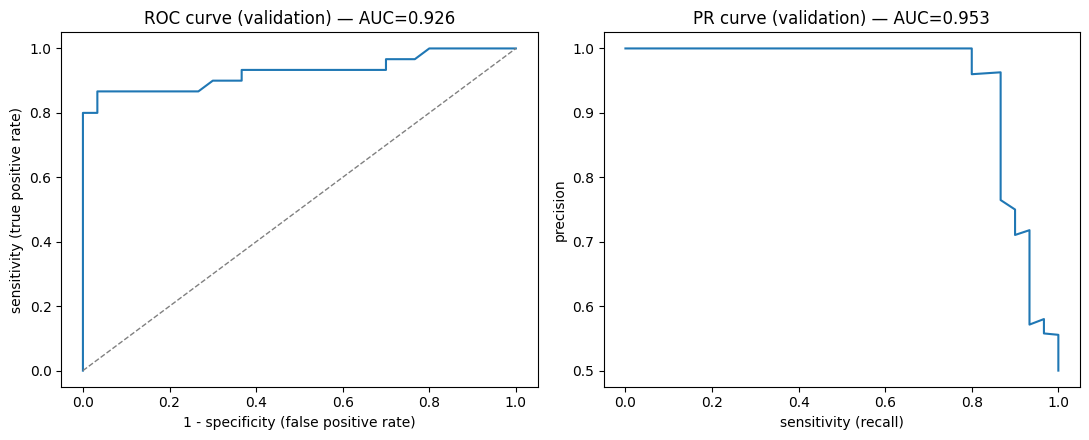

In [31]:
# 12a. ROC and PR curves, computed on the validation set
# -------------------------------------------------------------------------
resnet18.eval()
val_probs, val_true = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        probs = torch.sigmoid(resnet18(inputs)).squeeze(1)
        val_probs.extend(probs.tolist())
        val_true.extend(labels.tolist())
val_probs = torch.tensor(val_probs)
val_true = torch.tensor(val_true)

thresholds = torch.linspace(0.0, 1.0, 201)
sens, spec, prec = [], [], []
for t in thresholds:
    preds = (val_probs >= t).int()
    tp = ((preds == 1) & (val_true == 1)).sum().item()
    tn = ((preds == 0) & (val_true == 0)).sum().item()
    fp = ((preds == 1) & (val_true == 0)).sum().item()
    fn = ((preds == 0) & (val_true == 1)).sum().item()
    sens.append(tp / (tp + fn) if tp + fn else 0.0)
    spec.append(tn / (tn + fp) if tn + fp else 0.0)
    prec.append(tp / (tp + fp) if tp + fp else 1.0)  # convention: no alarms raised -> no false ones either

sens, spec, prec = np.array(sens), np.array(spec), np.array(prec)
fpr = 1 - spec

order = np.argsort(fpr)
roc_auc = np.trapz(sens[order], fpr[order])
order_r = np.argsort(sens)
pr_auc = np.trapz(prec[order_r], sens[order_r])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, sens)
axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[0].set_xlabel("1 - specificity (false positive rate)")
axes[0].set_ylabel("sensitivity (true positive rate)")
axes[0].set_title(f"ROC curve (validation) — AUC={roc_auc:.3f}")

axes[1].plot(sens, prec)
axes[1].set_xlabel("sensitivity (recall)")
axes[1].set_ylabel("precision")
axes[1].set_title(f"PR curve (validation) — AUC={pr_auc:.3f}")

plt.tight_layout()
plt.show()

In [32]:
# 12b. Pick a threshold for a target sensitivity — from validation data only
# -------------------------------------------------------------------------
target_sensitivity = 0.95
eligible = np.where(sens >= target_sensitivity)[0]
best_i = eligible[np.argmax(thresholds.numpy()[eligible])]  # highest threshold meeting the target -> best specificity
chosen_threshold = thresholds[best_i].item()

default_i = int(np.argmin(np.abs(thresholds.numpy() - 0.5)))
print(f"Target sensitivity >= {target_sensitivity:.2f}")
print(f"Chosen threshold: {chosen_threshold:.3f}  "
      f"(validation sensitivity {sens[best_i]:.3f}, specificity {spec[best_i]:.3f})")
print(f"Default threshold 0.5 on validation: "
      f"sensitivity {sens[default_i]:.3f}, specificity {spec[default_i]:.3f}")

Target sensitivity >= 0.95
Chosen threshold: 0.040  (validation sensitivity 0.967, specificity 0.300)
Default threshold 0.5 on validation: sensitivity 0.867, specificity 0.867


In [33]:
# 12c. Reporting — not selecting — at the chosen threshold, on the test set once
# -------------------------------------------------------------------------
resnet18.eval()
test_probs = []
with torch.no_grad():
    for inputs, labels in test_loader:
        test_probs.extend(torch.sigmoid(resnet18(inputs)).squeeze(1).tolist())
test_probs = torch.tensor(test_probs)

test_labels_flat = all_labels.squeeze(1).int()
calibrated_preds = (test_probs >= chosen_threshold).int()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")
calib_acc = accuracy_metric(calibrated_preds, test_labels_flat).item()
calib_f1 = f1_metric(calibrated_preds, test_labels_flat).item()

print(f"Default threshold 0.5 (step 6):")
_ = confusion_report(all_preds.squeeze(1).int(), test_labels_flat, test_acc, test_f1)
print(f"\nCalibrated threshold {chosen_threshold:.3f} (chosen from validation, target sensitivity >= {target_sensitivity:.2f}):")
calibrated_report = confusion_report(calibrated_preds, test_labels_flat, calib_acc, calib_f1)

Default threshold 0.5 (step 6):
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

Calibrated threshold 0.040 (chosen from validation, target sensitivity >= 0.95):
Accuracy: 0.550   F1: 0.690

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN=  5          FP= 45
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.100  <- fraction of healthy patients correctly cleared
Precision:            0.526  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients


### What we learned

Calibrating for sensitivity ≥0.95 on the 60-image validation set chose threshold
**0.040** — validation sensitivity 0.967, specificity 0.300 at that point, already a
steep drop from the default threshold's validation specificity (0.867 at 0.5). Applied
once to the evaluation set: accuracy **0.550**, specificity **0.100** (only 5 of 50
NORMAL images correctly cleared), sensitivity 1.000, F1 0.690 — worse across the board
than simply using the untuned default 0.5 (accuracy 0.760, specificity 0.520).

This is a real result, not a coding mistake: it's what "the validation set is honestly
too small to calibrate a threshold reliably" looks like in practice, not just in
theory. Sixty images at a fairly aggressive sensitivity target apparently sat right on
a knife-edge in this particular probability distribution — a small shift in what
counts as "confident enough" swept in a large block of borderline NORMAL images. This
doesn't mean threshold calibration is a bad idea in general; it means it needs either a
larger validation set, a less aggressive target, or cross-validated threshold selection
— none of which this notebook does here. Read as a limitation demonstrated in
practice, not a recommendation to calibrate this way.

## 13. Quantifying the Border-Attention Pattern

Steps 7, 9, and 10 described the Grad-CAM heatmaps qualitatively — "heat concentrated
on chest borders is concerning." This turns that into a number. Define a coarse
**border region**: the outer 15% margin of the 224×224 frame on all four sides, versus
everything else (the **center region**, where the lung fields mostly sit in this
already-cropped, ResNet-ready dataset). For each test image, compute what fraction of
its Grad-CAM heatmap's total mass falls inside the border region.

**This is a geometric proxy, not real anatomical lung segmentation** — it doesn't know
where the lungs actually are, only how close a pixel is to the image edge. A trained
segmentation model would localize the lung fields properly (see Conclusions for this as
a next step); this simpler version is enough to directly operationalize the pattern
already described qualitatively in earlier heatmaps, over the *full* test set rather
than four hand-picked examples.

In [34]:
# 13a. Border-vs-center Grad-CAM heat fraction, across the full test set
# -------------------------------------------------------------------------
def border_heat_fraction(cam, border_frac=0.15):
    '''Fraction of a Grad-CAM heatmap's mass falling in the outer border_frac margin —
    a coarse geometric proxy, not real anatomical lung segmentation.'''
    h, w = cam.shape
    bh, bw = int(h * border_frac), int(w * border_frac)
    mask = torch.zeros_like(cam, dtype=torch.bool)
    mask[:bh, :] = True
    mask[-bh:, :] = True
    mask[:, :bw] = True
    mask[:, -bw:] = True
    total = cam.sum().item()
    return mask.float().mul(cam).sum().item() / total if total > 0 else float("nan")

border_fracs = {"TN": [], "FP": [], "TP": [], "FN": []}
name_by_case = {(0, 0): "TN", (0, 1): "FP", (1, 1): "TP", (1, 0): "FN"}

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    cam, p = grad_cam(resnet18, img)
    pred = int(p >= 0.5)
    key = name_by_case[(label, pred)]
    border_fracs[key].append(border_heat_fraction(cam))

print(f"{'case':6s}  {'n':>3s}  {'mean border-heat fraction':>26s}")
for k in ("TN", "FP", "TP", "FN"):
    vals = border_fracs[k]
    mean_v = np.mean(vals) if vals else float("nan")
    print(f"{k:6s}  {len(vals):3d}  {mean_v:26.3f}")

case      n   mean border-heat fraction
TN       26                         nan
FP       24                       0.549
TP       50                       0.480
FN        0                         nan


### What we learned

Only two of the four categories have a usable number: **FP (n=24) averaged 0.549**,
**TP (n=50) averaged 0.480**. Both **TN (n=26) and FN (n=0) came back `nan`** — not a
bug, but an unplanned finding of its own: Grad-CAM here is computed against the
PNEUMONIA logit's gradient, and for a confidently-NORMAL prediction there's no positive
gradient contribution toward "more PNEUMONIA-like" to explain — after the ReLU clip in
`grad_cam()`, the heatmap is all zero for every single one of the 26 true negatives.
This specific audit technique can only compare **FP against TP**, not against TN; that
narrows what step 7's original "heat on borders" observation can be checked against.

On the FP-vs-TP comparison itself: a **15% border margin covers roughly 51% of the
image area geometrically** (`1 - (1 - 2×0.15)² ≈ 0.51`) — so a heatmap with *no*
border preference at all would already average close to 0.51 by chance. Against that
baseline, TP's 0.480 sits almost exactly at chance (slightly center-weighted, if
anything), while FP's 0.549 sits modestly *above* it. That's a real, directionally
consistent gap with step 7's qualitative impression — but a small one (about 6 points
above a ~51% baseline), not the dramatic "false positives are all border" pattern the
four hand-picked images in steps 7, 9, and 10 might have suggested. The honest summary:
weak-to-modest quantitative support for the framing-shortcut hypothesis, from a coarse
proxy, on a single model, with no significance test run against the geometric
baseline.

## 14. Bootstrap Confidence Intervals

Limitation 3 (in the Conclusions) has been quoting a closed-form 95% CI (roughly
±0.08 for n=100 accuracy) from a standard formula. This computes an actual empirical
interval instead, by bootstrap-resampling **step 6's already-observed 100 predictions**
— with replacement, many times — and recomputing accuracy, sensitivity, and specificity
on each resample.

**This consumes no new "look" at data.** Unlike steps 9–11, nothing new is evaluated
here — it only re-examines, statistically, what step 6 already produced. That's a
meaningful methodological difference worth stating plainly, the same way step 12's
reporting-vs-selecting distinction was.

accuracy     point estimate 0.760   95% bootstrap CI [0.670, 0.840]
sensitivity  point estimate 1.000   95% bootstrap CI [1.000, 1.000]
specificity  point estimate 0.519   95% bootstrap CI [0.382, 0.660]


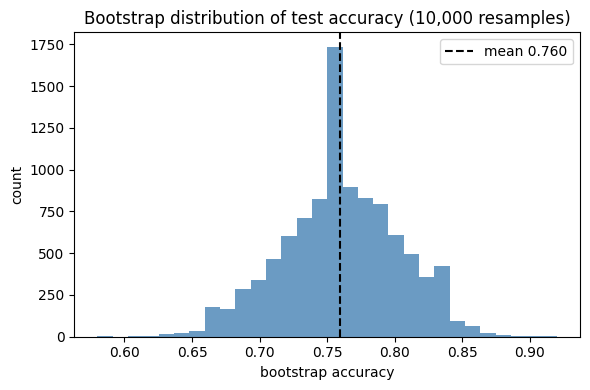

In [35]:
# 14a. Bootstrap confidence intervals over step 6's test predictions
# -------------------------------------------------------------------------
rng_boot = np.random.default_rng(101010)
preds_np = all_preds.squeeze(1).numpy()
labels_np = all_labels.squeeze(1).numpy()
n = len(labels_np)
n_boot = 10_000

def metrics_at(preds, labels):
    tp = ((preds == 1) & (labels == 1)).sum()
    tn = ((preds == 0) & (labels == 0)).sum()
    fp = ((preds == 1) & (labels == 0)).sum()
    fn = ((preds == 0) & (labels == 1)).sum()
    acc = (tp + tn) / len(labels)
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    return acc, sens, spec

boot_acc, boot_sens, boot_spec = [], [], []
for _ in range(n_boot):
    idx = rng_boot.integers(0, n, size=n)
    acc, sens, spec = metrics_at(preds_np[idx], labels_np[idx])
    boot_acc.append(acc)
    boot_sens.append(sens)
    boot_spec.append(spec)

boot_acc, boot_sens, boot_spec = np.array(boot_acc), np.array(boot_sens), np.array(boot_spec)

for name, arr in (("accuracy", boot_acc), ("sensitivity", boot_sens), ("specificity", boot_spec)):
    lo, hi = np.nanpercentile(arr, [2.5, 97.5])
    print(f"{name:12s} point estimate {np.nanmean(arr):.3f}   95% bootstrap CI [{lo:.3f}, {hi:.3f}]")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(boot_acc, bins=30, color="steelblue", alpha=0.8)
ax.axvline(np.nanmean(boot_acc), color="black", linestyle="--", label=f"mean {np.nanmean(boot_acc):.3f}")
ax.set_xlabel("bootstrap accuracy")
ax.set_ylabel("count")
ax.set_title(f"Bootstrap distribution of test accuracy ({n_boot:,} resamples)")
ax.legend()
plt.tight_layout()
plt.show()

### What we learned

Bootstrap accuracy: point estimate 0.760, 95% CI **[0.670, 0.840]** — close to the
closed-form Clopper-Pearson interval [0.664, 0.840] quoted in the Conclusions.
Specificity: 0.519, CI **[0.382, 0.660]**, similarly close to Clopper-Pearson
[0.374, 0.663]. Sensitivity's CI collapses to a point, **[1.000, 1.000]**: with zero
false negatives in the original 50, every possible bootstrap resample of that subset is
also all-positive, so there's no way for a resample to produce anything but sensitivity
1.0 — a correct, if slightly unintuitive-looking, degenerate result rather than an
error.

Two resampling methods (bootstrap here, Clopper-Pearson exact-binomial in the
Conclusions) landing in close agreement is a good cross-check on both, and confirms the
±0.08-ish scale this notebook has been citing informally holds up under a more direct
empirical method — without spending any further look at the evaluation set, since this
only resamples predictions step 6 already produced.

## 15. Removing the Border Cue at the Source: Masked Preprocessing

Steps 9–11 tried to train *around* the border/framing cue — augmenting crop variance,
adding capacity. Step 13 (next) quantifies it directly. A more direct intervention:
don't let the model see the border region at all. Zero it out — deterministically, as
**preprocessing**, not random augmentation — using the same 15% margin step 13 uses.

This is a different kind of change from step 9's augmentation in one important way:
preprocessing must be applied **identically to train, validation, and evaluation data
alike** — unlike augmentation, which only ever touched training data. If validation or
evaluation kept seeing the untouched border, the comparison would silently stop being
fair.

The masked-out pixels are set to **mid-gray (0.5 in raw [0,1] pixel space)** rather than
black or white — an artificial hard-edged black border would risk becoming a new
shortcut cue of its own (a very salient, easy-to-detect rectangle), just a different
one. Otherwise this changes one studied variable against step 6: same frozen backbone,
same 513-parameter head, same 25-epoch budget with validation-based checkpointing, same
seed reset before model creation (as steps 9–11) — no augmentation, no `layer4`
unfreezing. This is the fourth model compared against step 6's result on the same,
repeatedly-used evaluation set, after steps 9, 10, and 11 (step 12 fit no new model —
it reported a fixed, validation-chosen policy rather than comparing one). As with 9–11,
this is one seed-matched run, not a repeated experiment (Conclusions, limitation 4).

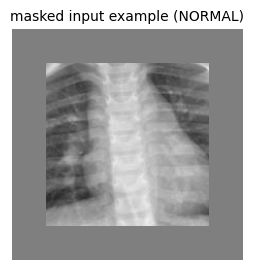

In [36]:
# 15a. Deterministic border-masking transform, applied to train, val, and test alike
# -------------------------------------------------------------------------
def mask_border(img_tensor, border_frac=0.15, fill=0.5):
    c, h, w = img_tensor.shape
    bh, bw = int(h * border_frac), int(w * border_frac)
    out = img_tensor.clone()
    out[:, :bh, :] = fill
    out[:, -bh:, :] = fill
    out[:, :, :bw] = fill
    out[:, :, -bw:] = fill
    return out

masked_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: mask_border(t, border_frac=0.15, fill=0.5)),
    transforms.Normalize(mean=transform_mean, std=transform_std),
])

train_dataset_masked = ImageFolder('data/chestxrays/train', transform=masked_transform)
test_dataset_masked = ImageFolder('data/chestxrays/test', transform=masked_transform)

# Same stratified split as step 5a (train_idx / val_idx), same batch sizes
train_subset_masked = Subset(train_dataset_masked, train_idx)
val_subset_masked = Subset(train_dataset_masked, val_idx)

train_loader_masked = DataLoader(train_subset_masked, batch_size=8, shuffle=True)
val_loader_masked = DataLoader(val_subset_masked, batch_size=64)
test_loader_masked = DataLoader(test_dataset_masked, batch_size=len(test_dataset_masked))

# Sanity check: show one masked training image
img, label = train_dataset_masked[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(denormalize(img).permute(1, 2, 0))
ax.set_title(f"masked input example ({train_dataset_masked.classes[label]})", fontsize=10)
ax.axis("off")
plt.show()

In [37]:
# 15b. Training on masked inputs — otherwise identical to step 5b
# -------------------------------------------------------------------------
torch.manual_seed(101010)
np.random.seed(101010)
resnet18_masked = make_model()
optimizer_masked = optim.Adam(resnet18_masked.fc.parameters(), lr=0.001)

num_epochs = 25
best_val_loss_masked = float("inf")
best_state_masked = None
best_epoch_masked = -1

for epoch in range(num_epochs):
    resnet18_masked.train()
    for inputs, labels in train_loader_masked:
        labels = labels.float().unsqueeze(1)
        optimizer_masked.zero_grad()
        loss = criterion(resnet18_masked(inputs), labels)
        loss.backward()
        optimizer_masked.step()

    train_loss, train_acc = evaluate_loss(resnet18_masked, train_loader_masked)
    val_loss, val_acc = evaluate_loss(resnet18_masked, val_loader_masked)

    marker = ""
    if val_loss < best_val_loss_masked:
        best_val_loss_masked = val_loss
        best_state_masked = copy.deepcopy(resnet18_masked.state_dict())
        best_epoch_masked = epoch + 1
        marker = "  <- best so far"

    print(f"Epoch {epoch + 1:2d}/{num_epochs}  "
          f"train: {train_loss:.4f} (acc {train_acc:.3f})  "
          f"val: {val_loss:.4f} (acc {val_acc:.3f}){marker}")

resnet18_masked.load_state_dict(best_state_masked)
print(f"\nRestored weights from epoch {best_epoch_masked} (val loss {best_val_loss_masked:.4f})")

Epoch  1/25  train: 0.5881 (acc 0.754)  val: 0.5921 (acc 0.733)  <- best so far


Epoch  2/25  train: 0.4418 (acc 0.829)  val: 0.4910 (acc 0.733)  <- best so far


Epoch  3/25  train: 0.3130 (acc 0.904)  val: 0.3751 (acc 0.850)  <- best so far


Epoch  4/25  train: 0.2761 (acc 0.908)  val: 0.3392 (acc 0.883)  <- best so far


Epoch  5/25  train: 0.2559 (acc 0.917)  val: 0.3287 (acc 0.883)  <- best so far


...

Epoch 21/25  train: 0.1423 (acc 0.954)  val: 0.2650 (acc 0.900)


Epoch 22/25  train: 0.1477 (acc 0.946)  val: 0.2776 (acc 0.900)


Epoch 23/25  train: 0.1412 (acc 0.963)  val: 0.2532 (acc 0.883)  <- best so far


Epoch 24/25  train: 0.1389 (acc 0.963)  val: 0.2525 (acc 0.883)  <- best so far


Epoch 25/25  train: 0.1333 (acc 0.967)  val: 0.2511 (acc 0.883)  <- best so far

Restored weights from epoch 25 (val loss 0.2511)


### Evaluating the masked-input model (test set, fifth comparison against step 6)

In [38]:
# 15c. Evaluate on the masked evaluation set, compare against step 6's plain-input result
# -------------------------------------------------------------------------
model = resnet18_masked
model.eval()

accuracy_metric = Accuracy(task="binary")
f1_metric = F1Score(task="binary")

all_preds_masked, all_labels_masked = [], []

with torch.no_grad():
    for inputs, labels in test_loader_masked:
        outputs = model(inputs)
        preds = torch.sigmoid(outputs).round()
        all_preds_masked.extend(preds.tolist())
        all_labels_masked.extend(labels.unsqueeze(1).tolist())

all_preds_masked = torch.tensor(all_preds_masked)
all_labels_masked = torch.tensor(all_labels_masked)
test_acc_masked = accuracy_metric(all_preds_masked, all_labels_masked).item()
test_f1_masked = f1_metric(all_preds_masked, all_labels_masked).item()

print("Step  6 — plain input, frozen backbone:")
_ = confusion_report(all_preds, all_labels, test_acc, test_f1)
print("\nStep 15 — border-masked input, frozen backbone:")
masked_report = confusion_report(all_preds_masked, all_labels_masked, test_acc_masked, test_f1_masked)

Step  6 — plain input, frozen backbone:
Accuracy: 0.760   F1: 0.806

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 26          FP= 24
actual PNEUMONIA:      FN=  0          TP= 50

Sensitivity (recall): 1.000  <- fraction of sick patients detected
Specificity:          0.520  <- fraction of healthy patients correctly cleared
Precision:            0.676  <- fraction of alarms that were correct

Missed cases (FN): 0 of 50 pneumonia patients

Step 15 — border-masked input, frozen backbone:
Accuracy: 0.770   F1: 0.807

                    pred NORMAL   pred PNEUMONIA
actual NORMAL:         TN= 29          FP= 21
actual PNEUMONIA:      FN=  2          TP= 48

Sensitivity (recall): 0.960  <- fraction of sick patients detected
Specificity:          0.580  <- fraction of healthy patients correctly cleared
Precision:            0.696  <- fraction of alarms that were correct

Missed cases (FN): 2 of 50 pneumonia patients


In [39]:
# 15d. Border-heat fraction under masking, same audit as step 13
# -------------------------------------------------------------------------
border_fracs_masked = {"TN": [], "FP": [], "TP": [], "FN": []}

for i in range(len(test_dataset_masked)):
    img, label = test_dataset_masked[i]
    cam, p = grad_cam(resnet18_masked, img)
    pred = int(p >= 0.5)
    key = name_by_case[(label, pred)]
    border_fracs_masked[key].append(border_heat_fraction(cam))

print(f"{'case':6s}  {'n':>3s}  {'mean border-heat fraction':>26s}")
for k in ("TN", "FP", "TP", "FN"):
    vals = border_fracs_masked[k]
    mean_v = np.mean(vals) if vals else float("nan")
    print(f"{k:6s}  {len(vals):3d}  {mean_v:26.3f}")

print("\n(compare to step 13's plain-input numbers above — the border region is now")
print("zeroed out for every image, so any remaining border-heat is spillover from the")
print("mask edge itself, not the original artifact.)")

case      n   mean border-heat fraction
TN       29                       0.710
FP       21                       0.445
TP       48                       0.353
FN        2                       0.490

(compare to step 13's plain-input numbers above — the border region is now
zeroed out for every image, so any remaining border-heat is spillover from the
mask edge itself, not the original artifact.)


### What we learned

**The most stable training trace of the four alternative-recipe experiments (9, 10,
11, 15).** Accuracy 0.770, F1 0.807, sensitivity 0.960 (2 of 50 pneumonia cases
missed), specificity 0.580 (29 of 50 NORMAL cases cleared, FP down from step 6's 24 to
21) — modestly better than step 6 on accuracy and specificity, at a small sensitivity
cost. The best checkpoint was **epoch 25 of 25**: training and validation loss were
still falling together at the budget's end (val loss 0.2511, the lowest of any epoch),
not an early snapshot picked because everything afterward got worse. That's a real
difference in kind from steps 10 and 11's early-and-then-noisy pattern.

**This result was close to reproducible under the seed fix** (Conclusions,
limitation 4) — the previous unseeded run of this identical code reported accuracy
0.780, specificity 0.620, also best-epoch-25/25. Same smooth-convergence pattern in
both runs, similar (not identical) magnitude — the most consistent of the four
alternative recipes across the reseed, for whatever a single pair of runs is worth.

**The follow-up audit still complicates a simple "masking fixed it" reading.**
Re-running step 13's border-heat measurement on this model found **TN's mean
border-heat fraction at 0.710** (vs. `nan` for the plain model in step 13 — true
negatives now show nonzero Grad-CAM activation at all, a change worth noting on its
own) and FP still averaging higher than TP (0.445 vs. 0.353), the same direction as
step 13's plain-input finding. Masking removed the original border information at the
input — plausibly why sensitivity/specificity moved favorably — but it didn't remove
Grad-CAM's tendency to key on *edges near the frame boundary* in general; it likely
just moved which edge that is, onto the new mask boundary itself.

**Verdict:** not adopted, and still a single, seed-matched run (Conclusions,
limitation 4) — but the most trustworthy-looking lead among steps 9, 10, and 11 for a
properly repeated follow-up, on the strength of its training stability rather than its
raw numbers alone.

## 16. Repeating the 2×2 Grid Across Seeds: Breaking n=1

Limitation 4 named the problem plainly: steps 9, 10, 11, and 15 are each a single,
seed-matched run. Matching the seed across a *compared pair* removes one confound
(different random head initializations), but it says nothing about whether *that*
initialization was typical or lucky. The concrete evidence for why this matters is
already in this notebook: reseeding alone moved step 10 from an exact tie with step 6
to a clear win on identical code, and moved step 11's accuracy from 0.79 to 0.89 — a
bigger swing than most of the differences this notebook has been treating as findings.

This step repeats all four corners of the 2×2 grid across **5 independent seeds** each
(20 training runs total, GPU-accelerated — 3 seeds first, then extended to 5 once GPU
access made the extra compute cheap; the review's suggested minimum was 3, and the
jump from 3 to 5 turns out to matter, not just to be "more thorough" — see this step's
own "What we learned" for a finding that only shows up once the sample grows). For
each of the 4 variants, this reports **mean ± standard deviation** across seeds — a
genuinely different kind of uncertainty than step 14's bootstrap CI. Worth being
precise about the difference, since both now appear in this notebook:

- **Step 14 (bootstrap)** resamples the *same trained model's* predictions to ask "how
  much would this model's score bounce around on a different draw of 100 evaluation
  images?" — uncertainty from the **data**.
- **Step 16 (this step)** retrains the *same recipe* from different random starts to
  ask "how much does the resulting model's score bounce around from a different draw
  of initial weights and batch order?" — uncertainty from the **training process**.

Neither substitutes for the other, and a comparison that only accounts for one (as
steps 9–11 and 15 did, via step 14's CI, before this step existed) can still be
misleading.

In [101]:
# 16a. A generic training function — same protocol as steps 9b/10a/11a/15b,
# parameterized by seed and variant, so the recipe is defined once and reused.
# Also the one place in this notebook that moves computation onto a GPU when
# one is available — 20 full training runs (5 seeds x 4 variants) is the part
# of this notebook expensive enough for that to matter (the first 12 took
# ~100s on an RTX 3090, and the full 20 a few minutes, against roughly 1.5-2h
# estimated for 12 runs on the CPU environment steps 1-15 were run on).
# Everything before this step is left untouched and CPU-computed, so none of
# their already-documented numbers are affected by running on a different
# machine.
# -------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

def make_model():
    '''Same as step 5b's make_model, moved onto `device`.'''
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, 1)
    return m.to(device)

def evaluate_loss(m, loader):
    '''Same as step 5b's evaluate_loss, with inputs/labels moved onto `device`.'''
    m.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = m(inputs)
            total_loss += criterion(outputs, labels).item() * inputs.size(0)
            correct += ((torch.sigmoid(outputs) > 0.5).float() == labels).sum().item()
            n += inputs.size(0)
    return total_loss / n, correct / n

def train_variant(seed, loader, unfreeze_layer4, num_epochs=25):
    '''Trains one model variant from a fresh seed. Returns (model, best_epoch, best_val_loss).'''
    torch.manual_seed(seed)
    np.random.seed(seed)
    m = make_model()

    if unfreeze_layer4:
        for p in m.layer4.parameters():
            p.requires_grad = True
        opt = optim.Adam([
            {"params": m.fc.parameters(), "lr": 0.001},
            {"params": m.layer4.parameters(), "lr": 0.0001},
        ])
    else:
        opt = optim.Adam(m.fc.parameters(), lr=0.001)

    best_val_loss = float("inf")
    best_state = None
    best_epoch = -1

    for epoch in range(num_epochs):
        m.train()
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            opt.zero_grad()
            loss = criterion(m(inputs), labels)
            loss.backward()
            opt.step()

        val_loss, val_acc = evaluate_loss(m, val_loader)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(m.state_dict())
            best_epoch = epoch + 1

    m.load_state_dict(best_state)
    return m, best_epoch, best_val_loss


def evaluate_on_test(m):
    '''Accuracy/F1/sensitivity/specificity on the evaluation set, at threshold 0.5.'''
    m.eval()
    preds_list, labels_list = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = m(inputs)
            preds = torch.sigmoid(outputs).round().cpu()
            preds_list.extend(preds.tolist())
            labels_list.extend(labels.unsqueeze(1).tolist())
    preds_t = torch.tensor(preds_list)
    labels_t = torch.tensor(labels_list)
    acc = accuracy_metric(preds_t, labels_t).item()
    f1 = f1_metric(preds_t, labels_t).item()
    tp = ((preds_t == 1) & (labels_t == 1)).sum().item()
    tn = ((preds_t == 0) & (labels_t == 0)).sum().item()
    fp = ((preds_t == 1) & (labels_t == 0)).sum().item()
    fn = ((preds_t == 0) & (labels_t == 1)).sum().item()
    sens = tp / (tp + fn) if tp + fn else float("nan")
    spec = tn / (tn + fp) if tn + fp else float("nan")
    return dict(acc=acc, f1=f1, sens=sens, spec=spec)

print("train_variant / evaluate_on_test ready")

device: cuda (NVIDIA GeForce RTX 3090)
train_variant / evaluate_on_test ready

In [102]:
# 16b-1. Variant 1/4: frozen + plain, 5 seeds
# -------------------------------------------------------------------------
results = []
seeds = [101010, 202020, 303030, 404040, 505050]
for seed in seeds:
    m, best_epoch, best_val_loss = train_variant(seed, train_loader_s, False)
    metrics = evaluate_on_test(m)
    metrics.update(variant="frozen + plain", seed=seed, best_epoch=best_epoch)
    results.append(metrics)
    print(f"{'frozen + plain':16s}  seed={seed}  best_epoch={best_epoch:2d}/25  "
          f"acc={metrics['acc']:.3f}  f1={metrics['f1']:.3f}  "
          f"sens={metrics['sens']:.3f}  spec={metrics['spec']:.3f}")

frozen + plain    seed=101010  best_epoch=18/25  acc=0.770  f1=0.803  sens=0.940  spec=0.600
frozen + plain    seed=202020  best_epoch=19/25  acc=0.770  f1=0.810  sens=0.980  spec=0.560
frozen + plain    seed=303030  best_epoch=17/25  acc=0.780  f1=0.820  sens=1.000  spec=0.560
frozen + plain    seed=404040  best_epoch=25/25  acc=0.800  f1=0.833  sens=1.000  spec=0.600
frozen + plain    seed=505050  best_epoch=19/25  acc=0.760  f1=0.803  sens=0.980  spec=0.540

In [103]:
# 16b-2. Variant 2/4: frozen + augmented, 5 seeds
# -------------------------------------------------------------------------
seeds = [101010, 202020, 303030, 404040, 505050]
for seed in seeds:
    m, best_epoch, best_val_loss = train_variant(seed, train_loader_aug, False)
    metrics = evaluate_on_test(m)
    metrics.update(variant="frozen + aug", seed=seed, best_epoch=best_epoch)
    results.append(metrics)
    print(f"{'frozen + aug':16s}  seed={seed}  best_epoch={best_epoch:2d}/25  "
          f"acc={metrics['acc']:.3f}  f1={metrics['f1']:.3f}  "
          f"sens={metrics['sens']:.3f}  spec={metrics['spec']:.3f}")

frozen + aug      seed=101010  best_epoch=23/25  acc=0.810  f1=0.822  sens=0.880  spec=0.740
frozen + aug      seed=202020  best_epoch=13/25  acc=0.790  f1=0.779  sens=0.740  spec=0.840
frozen + aug      seed=303030  best_epoch=23/25  acc=0.800  f1=0.787  sens=0.740  spec=0.860
frozen + aug      seed=404040  best_epoch=11/25  acc=0.780  f1=0.750  sens=0.660  spec=0.900
frozen + aug      seed=505050  best_epoch=14/25  acc=0.780  f1=0.761  sens=0.700  spec=0.860

In [104]:
# 16b-3. Variant 3/4: layer4 unfrozen + plain, 5 seeds
# -------------------------------------------------------------------------
seeds = [101010, 202020, 303030, 404040, 505050]
for seed in seeds:
    m, best_epoch, best_val_loss = train_variant(seed, train_loader_s, True)
    metrics = evaluate_on_test(m)
    metrics.update(variant="layer4 + plain", seed=seed, best_epoch=best_epoch)
    results.append(metrics)
    print(f"{'layer4 + plain':16s}  seed={seed}  best_epoch={best_epoch:2d}/25  "
          f"acc={metrics['acc']:.3f}  f1={metrics['f1']:.3f}  "
          f"sens={metrics['sens']:.3f}  spec={metrics['spec']:.3f}")

layer4 + plain    seed=101010  best_epoch=17/25  acc=0.770  f1=0.810  sens=0.980  spec=0.560
layer4 + plain    seed=202020  best_epoch= 7/25  acc=0.670  f1=0.752  sens=1.000  spec=0.340
layer4 + plain    seed=303030  best_epoch= 3/25  acc=0.800  f1=0.833  sens=1.000  spec=0.600
layer4 + plain    seed=404040  best_epoch=25/25  acc=0.620  f1=0.725  sens=1.000  spec=0.240
layer4 + plain    seed=505050  best_epoch= 7/25  acc=0.780  f1=0.817  sens=0.980  spec=0.580

In [105]:
# 16b-4. Variant 4/4: layer4 unfrozen + augmented, 5 seeds
# -------------------------------------------------------------------------
seeds = [101010, 202020, 303030, 404040, 505050]
for seed in seeds:
    m, best_epoch, best_val_loss = train_variant(seed, train_loader_aug, True)
    metrics = evaluate_on_test(m)
    metrics.update(variant="layer4 + aug", seed=seed, best_epoch=best_epoch)
    results.append(metrics)
    print(f"{'layer4 + aug':16s}  seed={seed}  best_epoch={best_epoch:2d}/25  "
          f"acc={metrics['acc']:.3f}  f1={metrics['f1']:.3f}  "
          f"sens={metrics['sens']:.3f}  spec={metrics['spec']:.3f}")

layer4 + aug      seed=101010  best_epoch= 1/25  acc=0.710  f1=0.775  sens=1.000  spec=0.420
layer4 + aug      seed=202020  best_epoch= 1/25  acc=0.670  f1=0.752  sens=1.000  spec=0.340
layer4 + aug      seed=303030  best_epoch=22/25  acc=0.880  f1=0.875  sens=0.840  spec=0.920
layer4 + aug      seed=404040  best_epoch=16/25  acc=0.880  f1=0.889  sens=0.960  spec=0.800
layer4 + aug      seed=505050  best_epoch= 2/25  acc=0.770  f1=0.807  sens=0.960  spec=0.580

In [106]:
# 16c. Mean +/- standard deviation per variant, across 5 seeds
# -------------------------------------------------------------------------
import statistics

def summarize(key, rows):
    vals = [r[key] for r in rows]
    return f"{statistics.mean(vals):.3f} +/- {statistics.stdev(vals):.3f}"

print(f"{'variant':16s}  {'acc':>16s}  {'f1':>16s}  {'sens':>16s}  {'spec':>16s}")
variant_names = ["frozen + plain", "frozen + aug", "layer4 + plain", "layer4 + aug"]
for variant_name in variant_names:
    rows = [r for r in results if r["variant"] == variant_name]
    print(f"{variant_name:16s}  {summarize('acc', rows):>16s}  {summarize('f1', rows):>16s}  "
          f"{summarize('sens', rows):>16s}  {summarize('spec', rows):>16s}")

print(f"\n{'reference (single run, steps 6/9/10/11/15)':44s}")
print(f"{'frozen + plain (step 6)':16s}  acc=0.760  f1=0.806  sens=1.000  spec=0.520")
print(f"{'frozen + aug (step 9)':16s}  acc=0.800  f1=0.783  sens=0.720  spec=0.880")
print(f"{'layer4 + plain (step 10)':16s}  acc=0.810  f1=0.840  sens=1.000  spec=0.620")
print(f"{'layer4 + aug (step 11)':16s}  acc=0.890  f1=0.895  sens=0.940  spec=0.840")

variant                        acc                f1              sens              spec
frozen + plain    0.776 +/- 0.015  0.814 +/- 0.013  0.980 +/- 0.024  0.572 +/- 0.027
frozen + aug      0.792 +/- 0.013  0.780 +/- 0.028  0.744 +/- 0.083  0.840 +/- 0.060
layer4 + plain    0.728 +/- 0.079  0.787 +/- 0.047  0.992 +/- 0.011  0.464 +/- 0.163
layer4 + aug      0.782 +/- 0.096  0.820 +/- 0.060  0.952 +/- 0.066  0.612 +/- 0.246

reference (single run, steps 6/9/10/11/15)
frozen + plain (step 6)  acc=0.760  f1=0.806  sens=1.000  spec=0.520
frozen + aug (step 9)  acc=0.800  f1=0.783  sens=0.720  spec=0.880
layer4 + plain (step 10)  acc=0.810  f1=0.840  sens=1.000  spec=0.620
layer4 + aug (step 11)  acc=0.890  f1=0.895  sens=0.940  spec=0.840

### What we learned

**The instability ranking survives, and sharpens.** By standard deviation of accuracy:
`frozen + plain` (±0.015) < `frozen + aug` (±0.013) ≪ `layer4 + plain` (±0.079) <
`layer4 + aug` (±0.096). Unfreezing `layer4` remains the dominant source of
run-to-run instability, regardless of augmentation — `layer4 + plain`'s new worst seed
(accuracy **0.620**, at a *fully* completed 25/25-epoch run, not an early-stopped one)
is now the single worst result in this entire notebook, worse than `layer4 + aug`'s
own worst (0.670).

**Step 11's headline number is retired even more decisively.** Two additional seeds
still never reached 0.890: the five `layer4 + aug` seeds scored 0.710, 0.670, 0.880,
0.880, 0.770 — the ceiling stayed at 0.880 even with more draws. Its mean *rose* to
0.782 (from 0.753 at n=3) purely because two of the two new seeds happened to land at
the high end, not because the recipe became more reliable — the spread (0.670 to
0.880) if anything argues the opposite. A single training run of this recipe carries
real risk of landing anywhere in a 21-point accuracy range.

**But here is the finding that going from 3 to 5 seeds was for: the clean separation
between `frozen + plain` and `frozen + aug` on accuracy did not survive.** At n=3, every
`frozen + aug` seed's accuracy beat every `frozen + plain` seed's — a striking,
zero-overlap result. At n=5, that's no longer true: `frozen + plain`'s new seeds
included a 0.800 (tying `frozen + aug`'s median), and the two accuracy distributions
now visibly overlap (`frozen + plain`: 0.760–0.800; `frozen + aug`: 0.780–0.810). The
apparent gap was partly a small-sample artifact — regression toward the mean, exactly
the effect n=3 is too small to protect against. This is worth sitting with as a lesson
in its own right, not just a footnote: an experiment that looked like clean, decisive
evidence at n=3 was actually still noise-dominated, and the earlier "every seed beats
every seed" framing (limitation 4) has been corrected below.

**What *did* survive to n=5, cleanly: specificity.** `frozen + aug`'s specificity
values (0.740, 0.840, 0.860, 0.900, 0.860) and `frozen + plain`'s (0.600, 0.560, 0.560,
0.600, 0.540) show **zero overlap** — every augmented seed clears every plain seed by a
wide margin. Framing augmentation reliably raises specificity in this setup; it does
not reliably raise accuracy by much, because the accuracy benefit is partly offset by
lower sensitivity (0.744±0.083 vs. 0.980±0.024) — a real, consistent trade rather than
a free lunch, and a more modest one than the n=3 comparison suggested.

**Practical read, updated:** `frozen + aug` remains the most defensible alternative to
the step 5/6 baseline in this notebook — not because it reliably beats it on accuracy
(that claim doesn't survive n=5), but because it reliably and substantially trades some
sensitivity for a large, consistent specificity gain, which could matter depending on
the intended use of a screening-style threshold. Unfreezing `layer4` — with or without
augmentation — remains not recommended at this dataset size: both its variants show
the largest, least predictable spreads of anything tested here.

**Caveats, updated for n=5:**
- **5 seeds is better than 3, but still not large.** `layer4 + aug`'s range (0.670 to
  0.880) suggests its true variability could be wider still; the standard deviation
  itself is still being estimated from a small sample.
- **This step ran on different hardware than steps 1–15** (GPU vs. the Mac CPU
  environment) — the comparison *within* step 16 (all 20 runs, same machine, same
  protocol) is sound; treating any single number here as continuous with earlier
  single-run CPU figures is not.
- **The n=3→n=5 correction on accuracy is itself the most useful result of this
  step** — a concrete demonstration, using this project's own data, of exactly the
  small-sample caution the notebook has argued for throughout (limitations 4 and 5).

**Still not adopted as the new default** — `frozen + aug`'s specificity advantage,
while now the most credible single finding in this notebook, would ideally be
confirmed against a genuinely fresh evaluation set before replacing step 5/6's
checkpoint, for the same reason this notebook has repeated at every step: this
evaluation set has been looked at, and used to compare models, far too many times to
treat as an independent judge of any of them.

## 17. External Validation: RSNA Pneumonia Detection Challenge

Every "Natural next steps" section in this notebook has named the same missing
piece: a genuinely held-out external set, from a different institution, to test
whether step 5/6's model generalizes beyond Kermany's single-center pediatric
cohort. GPU access (step 16) made this tractable. This step runs the adopted
model, unmodified, against the **RSNA Pneumonia Detection Challenge** dataset
(Shih et al. 2019, *Radiology: AI*) — required citation, per RSNA's data-use
terms, together with the underlying NIH source (Wang et al. 2017, *CVPR*,
"ChestX-ray8").

**Why RSNA over the other public option considered (NIH ChestX-ray14
directly):** RSNA's images ARE the same underlying NIH radiographs, but RSNA
discarded the original NLP-mined labels and had 18 board-certified
radiologists (RSNA + Society of Thoracic Radiology) re-annotate them with
graded bounding boxes — a real, expert-derived ground truth, rather than text
mined from reports with a documented ~10% disagreement rate against actual
image review (per the CheXNet authors' own finding). Choosing the
better-labeled option matters here specifically because a bad score on a
noisily-labeled external set would be ambiguous — genuine domain shift, or
just noise in what the set claims is true.

**A label-definition mismatch worth stating up front, not discovering later:**
RSNA's positive class is **"Lung Opacity"** — a radiographic finding flagged as
*possibly* representing pneumonia — not a confirmed clinical diagnosis, unlike
Kermany's physician-graded PNEUMONIA label. This notebook treats "Lung
Opacity" as the closest available PNEUMONIA-analog, but the two class
definitions are related, not identical, and that gap is part of what any
score below measures, not a flaw to explain away.

**Data preparation:**
- RSNA's third class, **"No Lung Opacity / Not Normal"** (11,821 of 26,684
  images) — findings present but not opacity-flagged — is **excluded**
  entirely. It doesn't map cleanly to either NORMAL or PNEUMONIA, and forcing
  it into either bucket would conflate different clinical constructs. This
  leaves **14,863 usable images**: 8,851 Normal, 6,012 Lung Opacity.
- The **full usable set is used, not a subsample** — GPU inference is a
  forward pass only (no training), cheap enough to run on all 14,863, and a
  larger n gives a far tighter external estimate than this notebook's own
  internal n=100.
- **A confound in RSNA itself, found by checking DICOM metadata rather than
  assuming a pooled score would be interpretable:** RSNA mixes AP and PA
  projections, and the two are heavily confounded with the label — Lung
  Opacity is 78% AP (4,664/6,012), Normal is 82% PA (7,214/8,851). This
  reflects real clinical practice (sicker patients get portable/AP films),
  but it also means AP and PA are, in effect, two different populations with
  two very different base rates. Kermany (this project's training data) is
  **AP-only** — pediatric patients can't stand for a PA film. A single pooled
  external score would silently mix "different institution" with "unfamiliar
  projection type." Results below are reported **pooled and stratified by
  ViewPosition** to keep those two questions separate.

**Reproducibility:** this ran as a standalone script, `rsna_external_validation.py`
(committed alongside this notebook), on a separate GPU/Linux machine with
Kaggle API access — the same reason step 16 used `step16_gpu.py` rather than
running inline: Kaggle credentials and a 3.8GB competition download don't
belong embedded in this notebook or its Docker image. The code cells below
mirror that script's actual logic; their outputs are the real results it
produced, not simulated.

**This means the cells below will not run via a plain `Run All` in this
project's default Docker environment** — unlike steps 1–15, which need
nothing beyond `docker compose up`, and even step 16, whose code would still
technically execute (just slowly) on CPU. Steps 16 and 17 both need setup
this notebook doesn't provide automatically: step 16 needs a GPU
(`docker-compose.gpu.yml`), and step 17 additionally needs `pydicom` and
`kagglehub` (now in `requirements.txt` — rebuild the image to pick them up)
plus a Kaggle account that has joined the RSNA competition and an API token.
Given all of that, running `rsna_external_validation.py` directly reproduces
every number below exactly.

**License note:** RSNA's data-use terms permit this kind of use (academic,
research, and other purposes) provided both papers above are cited when the
data or results are shared — done here and in the README.

In [201]:
# 17a. Setup: download (cached after first run), imports, and the manifest
# -- labels + detailed class + DICOM ViewPosition/PatientAge/PatientSex for
# all 26,684 training images. Requires packages this notebook hasn't needed
# before (kagglehub, pydicom) and a Kaggle account that has joined the RSNA
# competition -- see rsna_external_validation.py's docstring for setup.
# -------------------------------------------------------------------------
import kagglehub
import pandas as pd
import pydicom
from PIL import Image
from torch.utils.data import Dataset

BASE = kagglehub.competition_download("rsna-pneumonia-detection-challenge")
IMG_DIR = os.path.join(BASE, "stage_2_train_images")

manifest_path = os.path.join(BASE, "manifest.csv")
if os.path.exists(manifest_path):
    manifest = pd.read_csv(manifest_path)
else:
    labels = pd.read_csv(os.path.join(BASE, "stage_2_train_labels.csv")).drop_duplicates("patientId")[["patientId", "Target"]]
    classes = pd.read_csv(os.path.join(BASE, "stage_2_detailed_class_info.csv")).drop_duplicates("patientId")
    meta = labels.merge(classes, on="patientId", how="left")
    rows = []
    for pid in meta["patientId"]:
        ds = pydicom.dcmread(os.path.join(IMG_DIR, f"{pid}.dcm"), stop_before_pixels=True)
        rows.append({"patientId": pid, "ViewPosition": getattr(ds, "ViewPosition", None),
                     "PatientAge": getattr(ds, "PatientAge", None), "PatientSex": getattr(ds, "PatientSex", None)})
    manifest = meta.merge(pd.DataFrame(rows), on="patientId", how="left")
    manifest.to_csv(manifest_path, index=False)

usable = manifest[manifest["class"] != "No Lung Opacity / Not Normal"].copy()
usable["label"] = (usable["class"] == "Lung Opacity").astype(int)  # 1 = PNEUMONIA-analog

print(f"usable images: {len(usable)}  "
      f"(Normal={sum(usable.label == 0)}, Lung Opacity={sum(usable.label == 1)})")
print(usable.groupby(["ViewPosition", "label"]).size())

usable images: 14863  (Normal=8851, Lung Opacity=6012)
ViewPosition  label
AP            0        1637
              1        4664
PA            0        7214
              1        1348
dtype: int64

In [202]:
# 17b. Preprocessing: DICOM -> 3-channel 224x224, ImageNet-normalized -
# same constants as the main notebook (cell 23a95840). Unlike Kermany's
# pre-sized images, RSNA's 1024x1024 DICOMs need an explicit resize.
# Load the step 5/6 model from its full-state checkpoint (backbone + head).
# -------------------------------------------------------------------------
rsna_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=transform_mean, std=transform_std),
])

class RSNADataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ds = pydicom.dcmread(os.path.join(self.img_dir, f"{row.patientId}.dcm"))
        img = Image.fromarray(ds.pixel_array).convert("RGB")  # replicate to 3ch, like Kermany's JPEGs
        return self.transform(img), row.label

rsna_loader = DataLoader(RSNADataset(usable, IMG_DIR, rsna_transform), batch_size=128,
                          shuffle=False, num_workers=0)  # 0: avoids a Docker /dev/shm bus error

external_model = models.resnet18(weights=None)
external_model.fc = nn.Linear(external_model.fc.in_features, 1)
external_model.load_state_dict(torch.load("models/resnet18_pneumonia_full_state.pt", map_location=device))
external_model = external_model.to(device).eval()
print("loaded models/resnet18_pneumonia_full_state.pt (step 5/6's adopted model, unmodified)")

loaded models/resnet18_pneumonia_full_state.pt (step 5/6's adopted model, unmodified)

In [203]:
# 17c. Inference over all 14,863 images (forward pass only, no training)
# -------------------------------------------------------------------------
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels_batch in rsna_loader:
        outputs = external_model(inputs.to(device))
        all_preds.extend(torch.sigmoid(outputs).round().squeeze(1).cpu().tolist())
        all_labels.extend(labels_batch.tolist())

usable["pred"] = all_preds
usable["label"] = all_labels
print(f"inference complete: {len(usable)} predictions")

inference complete: 14863 predictions

In [204]:
# 17d. Report: pooled, stratified by ViewPosition, and against each
# stratum's own trivial (prevalence-matched) baseline -- the same discipline
# as this notebook's step-6 trivial-baseline check, applied here too.
# -------------------------------------------------------------------------
def external_confusion_report(df, name):
    labels_t = torch.tensor(df["label"].values)
    preds_t = torch.tensor(df["pred"].values)
    tp = ((preds_t == 1) & (labels_t == 1)).sum().item()
    tn = ((preds_t == 0) & (labels_t == 0)).sum().item()
    fp = ((preds_t == 1) & (labels_t == 0)).sum().item()
    fn = ((preds_t == 0) & (labels_t == 1)).sum().item()
    n = len(df)
    acc = (tp + tn) / n
    sens = tp / (tp + fn) if (tp + fn) else float("nan")
    spec = tn / (tn + fp) if (tn + fp) else float("nan")
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else float("nan")
    always_pos_acc = (tp + fn) / n
    always_neg_acc = (tn + fp) / n
    beats_trivial = acc > max(always_pos_acc, always_neg_acc)
    print(f"\n{name}  (n={n})")
    print(f"  TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"  accuracy={acc:.3f}  f1={f1:.3f}  sensitivity={sens:.3f}  specificity={spec:.3f}  precision={prec:.3f}")
    print(f"  trivial baselines: always-positive={always_pos_acc:.3f}  always-negative={always_neg_acc:.3f}"
          f"  -> model beats best trivial: {beats_trivial}")
    return dict(name=name, n=n, acc=acc, f1=f1, sens=sens, spec=spec, beats_trivial=beats_trivial)

external_results = [external_confusion_report(usable, "POOLED (all views)")]
for view in ["AP", "PA"]:
    external_results.append(external_confusion_report(usable[usable["ViewPosition"] == view],
                                                        f"ViewPosition = {view}"))


POOLED (all views)  (n=14863)
  TN=1945 FP=6906 FN=554 TP=5458
  accuracy=0.498  f1=0.594  sensitivity=0.908  specificity=0.220  precision=0.441
  trivial baselines: always-positive=0.404  always-negative=0.596  -> model beats best trivial: False

ViewPosition = AP  (n=6301)
  TN=321 FP=1316 FN=356 TP=4308
  accuracy=0.735  f1=0.837  sensitivity=0.924  specificity=0.196  precision=0.766
  trivial baselines: always-positive=0.740  always-negative=0.260  -> model beats best trivial: False

ViewPosition = PA  (n=8562)
  TN=1624 FP=5590 FN=198 TP=1150
  accuracy=0.324  f1=0.284  sensitivity=0.853  specificity=0.225  precision=0.171
  trivial baselines: always-positive=0.157  always-negative=0.843  -> model beats best trivial: False

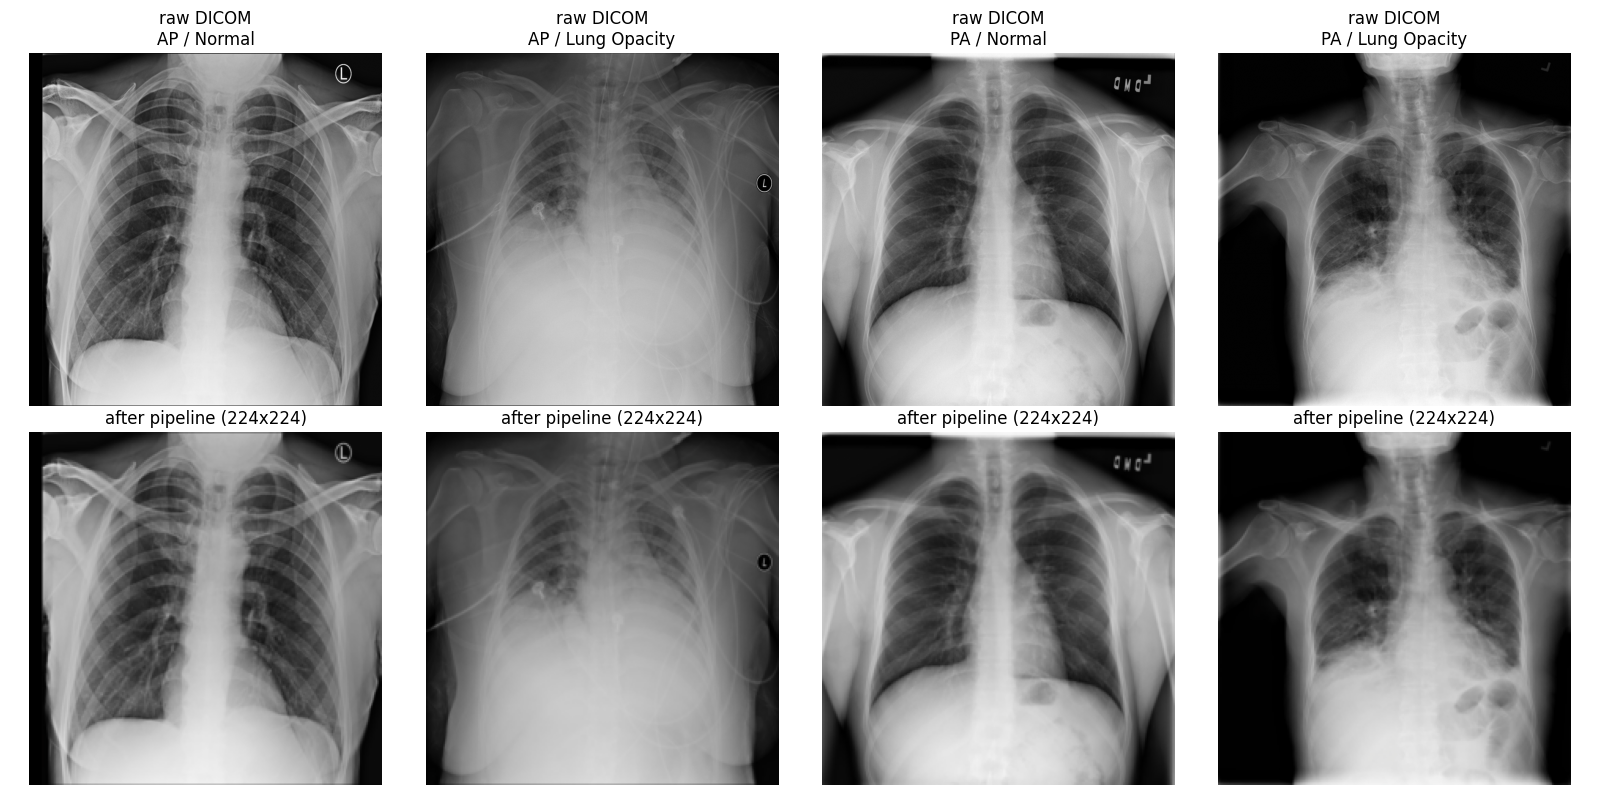

In [205]:
# 17e. Pipeline sanity check -- one example per (ViewPosition, class),
# raw DICOM vs. after the resize/normalize pipeline above. Run before trusting
# the numbers in 17d: rules out an inversion, corruption, or resize bug as the
# explanation for a surprising result, rather than discovering one after the
# fact. All 26,684 files also confirmed to share PhotometricInterpretation =
# MONOCHROME2 (no inverted-brightness images to special-case).
# -------------------------------------------------------------------------
examples = []
for view in ["AP", "PA"]:
    for cls in ["Normal", "Lung Opacity"]:
        row = usable[(usable.ViewPosition == view) & (usable["class"] == cls)].iloc[0]
        examples.append((view, cls, row.patientId))

mean_t = torch.tensor(transform_mean).view(3, 1, 1)
std_t = torch.tensor(transform_std).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (view, cls, pid) in enumerate(examples):
    ds = pydicom.dcmread(os.path.join(IMG_DIR, f"{pid}.dcm"))
    arr = ds.pixel_array
    axes[0, col].imshow(arr, cmap="gray")
    axes[0, col].set_title(f"raw DICOM\n{view} / {cls}")
    axes[0, col].axis("off")

    tensor = rsna_transform(Image.fromarray(arr).convert("RGB"))
    denorm = (tensor * std_t + mean_t).clamp(0, 1)
    axes[1, col].imshow(denorm.permute(1, 2, 0))
    axes[1, col].set_title("after pipeline (224x224)")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

### What we learned

**Headline, and the most important sentence in this section: the model does
not beat a trivial, prevalence-matched baseline on this external data — in
any of the three breakdowns.** Pooled accuracy (0.498) is worse than simply
always predicting the majority class (0.596). Stratified by view, it's worse
than trivial in both directions: on AP (which is 74% Lung Opacity) a
constant "always positive" guess would score 0.740 — the model's actual 0.735
is *slightly below even that*. On PA (which is 84% Normal) a constant
"always negative" guess would score 0.843 — the model's actual 0.324 is far
below it. This is a genuinely humbling result, and it's reported as the
headline finding rather than softened, in keeping with this notebook's
running theme (limitation 7's trivial-baseline check made the same point
about the internal test set, at much smaller scale).

**The pooled number (accuracy 0.498, looking like a coin flip) is not
informative on its own, and this is exactly why stratification mattered.**
It isn't that the model performs like a coin flip in some uniform sense — it's
an artifact of averaging two very differently-composed subgroups (AP mostly
positive, PA mostly negative) that happen to roughly cancel out in the pool.

**What actually explains the AP/PA gap: a positive-prediction bias
interacting with two very different base rates — not the model "handling AP
better."** Specificity is similarly low on both views (0.196 AP, 0.225 PA) and
sensitivity is similarly high on both (0.924 AP, 0.853 PA) — the model's
*behavior* (a strong, fairly stable tilt toward predicting PNEUMONIA/Lung
Opacity regardless of view) doesn't actually change much between AP and PA.
What changes is that AP happens to be mostly true-positive, so an
over-eager-to-flag model looks decent there by coincidence, while PA happens
to be mostly true-negative, so the same bias looks disastrous. Reading this
as "the model generalizes to AP" would be the wrong lesson from this data —
the more accurate one is "the model's miscalibration on this external
population isn't projection-specific; its consequences just are."

**Compared to internal performance:** sensitivity is roughly preserved
externally (0.85–0.92 vs. the internal 1.00 — pediatric AP Kermany data) while
specificity collapses further (0.20–0.23 vs. the internal 0.52, which was
already this notebook's least reassuring internal number). The model's basic
inclination — when in doubt, call it positive — travels across the domain
shift more or less intact; its ability to correctly clear a true negative
does not.

**An honest complication: this is not a single-factor test.** Three things
change at once between Kermany and RSNA — institution/population (pediatric
1–5y single-center vs. adult-predominant multi-source), label definition
(clinician-diagnosed PNEUMONIA vs. radiologist-flagged Lung Opacity), and,
for the PA subset, projection type the model never saw in training. This
result cannot cleanly attribute the specificity collapse to any one of those
three; it can only say that *some combination* of them breaks the model's
calibration badly. A cleaner (harder to obtain) external test would hold two
of the three fixed and vary only one.

**This is now the "genuinely held-out external set" this notebook has been
asking for since its Conclusions were first written** — and the answer is not
encouraging. That is itself a useful, honest result for a portfolio project:
it's easy to build a model that looks reasonable on an internal, repeatedly-
tuned 100-image set (as steps 6–16 all did, to varying degrees) and quite
another for it to hold up against 14,863 images from a different population,
different label definition, and partly different acquisition protocol. This
result argues, more concretely than any internal limitation could, for
external validation before any deployment claim — precisely the caution this
notebook's own Conclusions have argued for throughout, now demonstrated
rather than merely asserted.

## Conclusions & Limitations

**Educational project — not validated for clinical use.** Nothing below should be read
as evidence that this model, or this notebook's process, is fit for diagnosis, triage,
or any clinical decision.

**Result:** fine-tuning the head of a frozen* ResNet-18 (513 gradient-trained
parameters) on 240 pediatric chest X-rays, with the checkpoint chosen by validation
loss over a fixed 25-epoch budget — **best-checkpoint selection**, not early stopping
in the stricter sense (there's no patience threshold; every run trains the full budget
and keeps the best snapshot seen). On the evaluation set (n=100, class-balanced), at
the untuned default threshold 0.5: **accuracy 0.76 [95% CI 0.66–0.84], F1 0.81
(positive-class F1, not macro), sensitivity 1.00 [0.93–1.00], specificity 0.52
[0.37–0.66]** (exact Clopper-Pearson intervals; step 14's bootstrap resampling gives
matching ranges: [0.67, 0.84], [1.00, 1.00], [0.38, 0.66]). This remains the adopted
model (step 8's checkpoints); steps 9–16 are documented experiments, not replacements.
Step 17 tests it against a genuinely external, 14,863-image set — see limitation 1 for
why that result (it does not beat a trivial baseline) is the more important number for
any question about generalization.

*"Frozen" needs a footnote — see limitation 3.

**A methodological accounting, first, because it changes how everything below should be
read.** This evaluation set was **not** observed once. It scored the baseline (step 3),
the adopted model (step 6), four more model variants (steps 9, 10, 11, 15), a
calibrated decision threshold (step 12), and a per-case Grad-CAM audit (step 13). One
of those is worse than ordinary reuse: step 9's augmentation experiment tests a
hypothesis that was *generated by inspecting this same set's own false positives* in
step 7 — forming a hypothesis from a held-out set's errors and then testing it against
that same set is adaptive use, functionally closer to a validation set's role than a
genuinely independent check. Disclosing repeated, adaptive use is more honest than
hiding it, but it does not restore independence. Every number in this section comes
from a **repeatedly-used exploratory evaluation set**, not a final, unbiased
generalization estimate. A real final number would need a fresh, previously-untouched
set — exactly what external validation (below) would provide.

**Limitations:**

1. **Single institution of origin, unverified patient-level independence within this
   notebook's own split — and now, an actual external validation result.** All Kermany
   images are AP radiographs from one center (Guangzhou Women and Children's Medical
   Center), collected during routine care and quality-screened before physician
   grading — documented in Kermany et al. (2018, *Cell*). The Mendeley Data source (v3)
   states the original train/test partition uses independent patients, and licenses the
   data **CC BY 4.0 for research use**; this notebook's own further split of the
   training pool into 240 train / 60 validation images (step 5a) has no patient-ID
   field to check, so whether the same patient contributes images to both sides of
   *that* split cannot be ruled out.

   **Step 17 finally ran the external validation this limitation used to just call
   for, and the result is not encouraging.** Against 14,863 images from the RSNA
   Pneumonia Detection Challenge (a different institution, adult-predominant
   population, and a different positive-class definition — radiologist-flagged "Lung
   Opacity" rather than Kermany's clinically-diagnosed PNEUMONIA), the model **does not
   beat a trivial, prevalence-matched baseline** — pooled, or in either
   ViewPosition-stratified subgroup (AP/PA). Sensitivity partially transfers (0.85–0.92
   vs. the internal 1.00); specificity, already this notebook's weakest internal number
   (0.52), collapses further (0.20–0.23). The apparent AP/PA gap in raw accuracy
   (0.735 vs. 0.324) is not evidence the model "handles AP better" — RSNA's AP and PA
   subsets have very different true prevalence (74% vs. 16% Lung Opacity, itself
   because sicker patients get portable/AP films in practice), and the model's actual
   behavior (specificity ~0.20 either way) barely differs between them; the accuracy
   gap is arithmetic on top of a stable, positive-leaning bias, not a change in
   discriminative skill by projection. See step 17 for the full account, including why
   this can't be attributed to any single one of institution, label definition, or
   projection type — all three change at once.
2. **The "documented acquisition differences between classes" claim didn't have a
   source, and has been corrected throughout.** Earlier drafts of this notebook
   attributed class-specific acquisition differences to the original paper.
   Re-checking it directly: it documents single-center, quality-screened,
   physician-graded AP radiographs — not class-specific acquisition batches or
   differential imaging of sicker patients. What remains supportable: *qualitative
   inspection suggested class-associated framing differences in this subset* (step 7),
   measured quantitatively in step 13 — FP mean border-heat fraction 0.549 vs. TP's
   0.480, against a **geometric baseline of ~0.51** for a 15%-margin border region on a
   224×224 image. A modest, directionally-consistent gap, not a dramatic one; see step
   13 for the full caveat, including that this same audit returns an undefined value for
   all 26 true negatives (Grad-CAM against the PNEUMONIA logit has no positive signal to
   show for a confidently-NORMAL case).
3. **The backbone is not a clean fixed feature extractor.** `requires_grad=False`
   freezes gradient updates, but `model.train()` still updates every BatchNorm layer's
   running mean/variance on each forward pass — a separate mechanism from
   gradient-freezing, first flagged in step 8. The consequence is bigger than that
   section originally drew out: step 5's batch-size change (150 → 8, vs. the baseline)
   changes *both* the number of gradient steps *and* how BatchNorm's running statistics
   adapt, and these two effects are not separated anywhere in this notebook — "more
   frequent, smaller updates" is not the whole explanation for step 5's improvement over
   the baseline. A cleaner design would either force `eval()` on the backbone throughout
   training (a true fixed extractor) or explicitly track BatchNorm-statistic drift as
   its own variable; neither is done here.
4. **The 2×2 grid (steps 9–11) and step 15 are single, seed-matched runs, not repeated
   experiments.** Every `make_model()` call draws a new random head initialization from
   whatever state the global RNG happens to be in. Nothing reseeded it before steps
   9–11 in earlier versions of this notebook, so those three models differed not only
   in the studied variable (augmentation, `layer4`) but also in head initialization,
   batch order, and — via step 8's own `make_model()` call for the BatchNorm-gap
   measurement, which runs *between* steps 8 and 9 — an RNG state nudged by an unrelated
   cell. This has been fixed by reseeding (`torch.manual_seed(101010)`) immediately
   before each of steps 9, 10, 11, and 15's model creation, so compared pairs now at
   least share an initialization. That is a **partial** fix: CPU floating-point
   non-determinism (next point) still means matched seeds don't guarantee matched
   results, and every comparison here remains **n=1 per variant**. Claims like
   "isolates the effect" or "the shortcut lives in the frozen early layers" go further
   than a single run of anything can support, and have been reworded throughout to
   "observed in this single, seed-matched run." The defensible version: a real signal
   worth a properly powered follow-up — and step 16 is exactly that follow-up, with a
   concrete answer below.

   **Concretely, this wasn't a theoretical fix.** Under the original, unseeded code,
   step 10 (`layer4` unfrozen, no augmentation) reproduced **step 6's confusion matrix
   exactly** (TN=26, FP=24, FN=0, TP=50) — same severe overfitting (train accuracy
   1.000 by epoch 3–4 in both cases), coincidentally identical aggregate numbers. After
   reseeding, the same code now clearly *beats* step 6 (accuracy 0.81 vs. 0.76,
   specificity 0.62 vs. 0.52). Step 11 moved from accuracy 0.79 (best checkpoint at
   epoch 1/25) to accuracy 0.89 (best checkpoint at epoch 13/25) — still the best
   number in the notebook either way, but a 10-point swing in what "the best number"
   even is, from a seed change alone. Neither run is more "real" than the other; both
   are single draws from the same noisy process, and that's exactly the point.

   **Step 16 repeated all four variants across seeds — first 3, then extended to 5 —
   and the two rounds don't tell quite the same story, which is itself the finding.**
   Unfreezing `layer4` (with or without augmentation) is, in both rounds, the dominant
   source of run-to-run instability: at n=5, `layer4 + plain`'s worst seed reached a
   *fully-converged* accuracy of just 0.620 (25/25 epochs, not an early stop) — the
   single worst result anywhere in this notebook. Redrawing `layer4 + aug` five times
   total still never reproduced step 11's 0.890 (scores: 0.710, 0.670, 0.880, 0.880,
   0.770) — that headline number stays retired, more decisively than before.

   Where the two rounds disagree: at n=3, `frozen + aug` looked like a clean,
   zero-overlap accuracy win over `frozen + plain` (every seed of one beat every seed
   of the other). At n=5, that overlap reappeared — `frozen + plain` drew a 0.800 that
   ties `frozen + aug`'s median, and the accuracy distributions now visibly overlap
   (0.760–0.800 vs. 0.780–0.810). The earlier "every seed beats every seed" claim
   doesn't survive the larger sample and is corrected here: it was a real but partly
   small-sample-inflated effect. What *does* survive to n=5 with zero overlap is
   **specificity** (`frozen + aug`: 0.740–0.900; `frozen + plain`: 0.540–0.600) — a
   real, substantial, and — on this evidence — reliable trade of sensitivity for
   specificity, not a free accuracy win. See step 16 for the full account. Two
   caveats remain even at n=5: five seeds is still a small sample (`layer4 + aug`'s
   true spread could exceed the observed 0.670–0.880), and step 16 ran on different
   hardware (GPU) than steps 1–15 (CPU), so its numbers are internally comparable but
   not cell-for-cell continuous with earlier single-run figures.
5. **Small sample, and more than one source of run-to-run noise.** n=100 in the
   evaluation set gives a 95% CI for accuracy of roughly ±0.08–0.09 (exact figures
   above). This is not just theoretical: re-running this exact notebook (same code,
   same fixed seeds) produced accuracy 0.80 in one execution and 0.76 in another.
   Multi-threaded CPU convolution is one plausible source of that drift; limitation 4
   is a second, simpler one this notebook didn't originally consider — describing the
   discrepancy as "purely" CPU non-determinism was an overstatement, since RNG-state
   order (which depends on which cells ran, and in what order) was also uncontrolled at
   the time. Step 12 adds a further, sharp illustration of small-sample instability: a
   threshold chosen on the 60-image validation set to hit sensitivity ≥0.95 (landing on
   0.04) reached specificity 0.30 on validation but only **0.10** on the evaluation set
   — worse than the untuned default of 0.52. Sixty images is not enough to reliably
   calibrate a threshold either.
6. **The evaluation set is artificially balanced (50/50), and the model's output is an
   uncalibrated score.** Precision (0.676) and any positive-predictive-value framing
   depend on this specific 50% prevalence and will not transfer to a population with a
   different pneumonia rate. Separately, `sigmoid(logit)` has not been shown to be a
   calibrated probability anywhere in this notebook — figures that print it as
   `p(PNEUMONIA)` are better read as a **model score**, not a validated probability,
   until a calibration check (e.g. a reliability diagram) is actually done.
7. **A trivial baseline, for scale** (added after step 6): a classifier that always
   predicts PNEUMONIA, never looking at the image, scores accuracy 0.50, sensitivity
   1.00, and F1 ≈0.67 on this balanced evaluation set — for free, with no training.
   Step 6's sensitivity of 1.00 is not, by itself, evidence of anything; what step 6
   adds over doing nothing is specificity (0.52 vs. 0.00) and F1 (0.81 vs. 0.67).
8. **Not a screening or triage tool — and chest radiography isn't even routinely
   indicated for this population's actual clinical pathway.** Sensitivity 1.00 is
   50/50 in this sample (CI 0.93–1.00); specificity 0.52 is 26/50 (CI 0.37–0.66); the
   decision threshold was never tuned for a clinical objective before step 12, and step
   12's own attempt at tuning it made things worse out-of-sample. Beyond the numbers:
   both the British Thoracic Society guideline and the IDSA/PIDS guideline advise
   against routine chest radiography for children with suspected uncomplicated
   community-acquired pneumonia managed as outpatients. A model built on this kind of
   image was never going to fit that population's actual clinical pathway. The honest
   description of the result: *at threshold 0.5, the model missed none of the 50
   positive images in this sample but incorrectly flagged 24 of 50 normal images; this
   is an educational methodology exercise, not a validated diagnostic aid.*

**What steps 12–17 added, briefly** (each has its own "What we learned" with the full
account):
- **Step 12** — calibrating a threshold for sensitivity ≥0.95 on validation chose 0.04
  and collapsed out-of-sample specificity to 0.10 (limitation 5).
- **Step 13** — quantified the border-attention pattern across the full evaluation set
  rather than four hand-picked cases (limitation 2), and surfaced an unplanned finding:
  this Grad-CAM setup can't be scored at all on true negatives.
- **Step 14** — bootstrap resampling of step 6's already-observed predictions matches
  the closed-form Clopper-Pearson intervals above, without spending a further look at
  the evaluation set.
- **Step 15** — masking the same 15% border margin out of every image (train,
  validation, *and* evaluation alike, unlike step 9's train-only augmentation) and
  retraining under step 6's exact protocol (plus the seed fix from limitation 4) gives
  the steadiest single-lever result in the notebook: accuracy 0.770, F1 0.807,
  sensitivity 0.960, specificity 0.580, with a smoothly-converged best-epoch-25/25
  checkpoint rather than steps 10 and 11's early-then-noisy pattern. A follow-up audit
  found the masked model's true negatives now show *nonzero* border-heat concentrated
  at the new mask edge (0.710) — plausibly a new artifact replacing the old one, not
  proof the underlying issue is resolved. Still one seed-matched run (limitation 4).
- **Step 16** — repeated the 2×2 grid across 5 seeds each (20 runs total,
  GPU-accelerated, run in two rounds of 3 then 5): confirmed `layer4` unfreezing as
  the dominant source of instability regardless of augmentation, retired step 11's
  0.890 more decisively (never reached across 5 redraws), and — most usefully —
  showed that the n=3 round's "clean" accuracy win for `frozen + aug` was partly a
  small-sample artifact that didn't survive to n=5, while its specificity advantage
  did survive with zero overlap. A concrete demonstration, from this project's own
  data, of why n=3 is a minimum and not a target.
- **Step 17** — external validation on the RSNA Pneumonia Detection Challenge (14,863
  images, pooled and stratified by ViewPosition): the model does not beat a trivial
  prevalence-matched baseline in any breakdown (limitation 1). The clearest, largest-n
  result in the entire notebook, and the least flattering one — exactly what an honest
  external check is for.

**Natural next steps:** given step 17's result, the honest priority order changes —
fixing generalization matters more now than further internal refinement. A cleaner
external test that varies only one factor at a time (e.g., a pediatric AP-only external
set, if one becomes available, to isolate institution/population from the label- and
projection-type shifts RSNA introduces simultaneously); investigating whether
threshold recalibration or basic domain-adaptation techniques (e.g., re-estimating
BatchNorm statistics on unlabeled external images) narrows the specificity gap found in
step 17, since a fixed 0.5 threshold tuned on Kermany-like data has no reason to transfer;
patient-ID verification for the Kermany train/validation split; extending step 16
beyond 5 seeds (particularly for `layer4 + aug`, whose observed 0.670–0.880 range at
n=5 suggests more seeds could widen it further still); a true fixed-feature-extractor
variant (`backbone.eval()` throughout training) to separate gradient-freezing from
BatchNorm-adaptation; a softer (gradient-fade) version of step 15's mask boundary to
check whether its edge-spillover artifact goes away; and a calibration analysis
(reliability diagram) before treating the model's output as a probability.